In [1]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import json
def get_bcrp_fx_data_api():
    """
    Gets BCRP FX data using their API with correct parsing.
    Returns a dataframe with Date, Compra, Venta, and Mid columns.
    """
    
    # BCRP API endpoint format
    base_url = "https://estadisticas.bcrp.gob.pe/estadisticas/series/api"
    
    # Series codes
    compra_code = "PD04645PD"
    venta_code = "PD04646PD"
    
    # Date range
    start_date = "2000-01-03"
    end_date = datetime.now().strftime("%Y-%m-%d")
    
    # print("Fetching BCRP FX data via API...")
    print(f"Date range: {start_date} to {end_date}")
    
    try:
        # Fetch Compra
        url_compra = f"{base_url}/{compra_code}/json/{start_date}/{end_date}"
        print(f"Fetching Compra...")
        response_compra = requests.get(url_compra)
        response_compra.raise_for_status()
        data_compra = response_compra.json()
        
        # Fetch Venta
        url_venta = f"{base_url}/{venta_code}/json/{start_date}/{end_date}"
        print(f"Fetching Venta...")
        response_venta = requests.get(url_venta)
        response_venta.raise_for_status()
        data_venta = response_venta.json()
        
        # Parse the periods structure
        # Structure: {"config": {...}, "periods": [{"name": "19.Ene.04", "values": ["3.459"]}, ...]}
        
        if 'periods' not in data_compra or 'periods' not in data_venta:
            print("✗ 'periods' key not found in API response")
            return None
        
        # Extract data from periods
        dates_compra = []
        values_compra = []
        
        for period in data_compra['periods']:
            dates_compra.append(period['name'])
            # values is a list with one element (string)
            val = period['values'][0] if period['values'] else None
            values_compra.append(val)
        
        dates_venta = []
        values_venta = []
        
        for period in data_venta['periods']:
            dates_venta.append(period['name'])
            val = period['values'][0] if period['values'] else None
            values_venta.append(val)
        
        # Create dataframes
        df_compra = pd.DataFrame({
            'Date_str': dates_compra,
            'TC_Compra': values_compra
        })
        
        df_venta = pd.DataFrame({
            'Date_str': dates_venta,
            'TC_Venta': values_venta
        })
        
        # Parse dates - format like "19.Ene.04"
        def parse_bcrp_date(date_str):
            """Parse BCRP date format like '19.Ene.04' to datetime"""
            try:
                # Spanish month mapping
                months_es = {
                    'Ene': '01', 'Feb': '02', 'Mar': '03', 'Abr': '04',
                    'May': '05', 'Jun': '06', 'Jul': '07', 'Ago': '08',
                    'Set': '09', 'Oct': '10', 'Nov': '11', 'Dic': '12'
                }
                
                # Split by dots
                parts = date_str.split('.')
                day = parts[0]
                month_es = parts[1]
                year = parts[2]
                
                # Convert month to number
                month = months_es[month_es]
                
                # Determine century (assume 2000s for years 00-49, 1900s for 50-99)
                if int(year) >= 50:
                    year = '19' + year
                else:
                    year = '20' + year
                
                # Create date string and parse
                date_string = f"{year}-{month}-{day}"
                return pd.to_datetime(date_string)
            except Exception as e:
                return pd.NaT
        
        df_compra['Date'] = df_compra['Date_str'].apply(parse_bcrp_date)
        df_venta['Date'] = df_venta['Date_str'].apply(parse_bcrp_date)
        
        # Convert values to numeric (they're strings, and "n.d." becomes NaN)
        df_compra['TC_Compra'] = pd.to_numeric(df_compra['TC_Compra'], errors='coerce')
        df_venta['TC_Venta'] = pd.to_numeric(df_venta['TC_Venta'], errors='coerce')
        
        # Drop the string date column
        df_compra = df_compra[['Date', 'TC_Compra']]
        df_venta = df_venta[['Date', 'TC_Venta']]
        
        # Merge on Date
        df_merged = pd.merge(df_compra, df_venta, on='Date', how='outer')
        
        # Sort by date
        df_merged = df_merged.sort_values('Date').reset_index(drop=True)
        
        # Calculate mid price
        df_merged['TC_Mid'] = ((df_merged['TC_Compra'] + df_merged['TC_Venta']) / 2).round(4)
        
        # Remove rows where date is NaT
        df_merged = df_merged.dropna(subset=['Date'])
        
        # Remove rows where both compra and venta are NaN
        df_merged = df_merged.dropna(subset=['TC_Compra', 'TC_Venta'], how='all')
        
        print(f"\n{'='*60}")
        print("✓ Data retrieved successfully!")
        print(f"{'='*60}")
        print(f"Date range: {df_merged['Date'].min().strftime('%Y-%m-%d')} to {df_merged['Date'].max().strftime('%Y-%m-%d')}")
        print(f"Total observations: {len(df_merged)}")
        print(f"\nFirst 5 rows:")
        print(df_merged.head())
        print(f"\nLast 5 rows:")
        print(df_merged.tail())
        
        # Summary statistics
        print(f"\n{'='*60}")
        print("Summary Statistics")
        print(f"{'='*60}")
        print(df_merged[['TC_Compra', 'TC_Venta', 'TC_Mid']].describe())
        
        return df_merged
        
    except Exception as e:
        print(f"✗ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

# Execute
df_fx = get_bcrp_fx_data_api()

# The dataframe is now stored in df_fx variable
# Access it like:
# df_fx['TC_Mid']  # for mid prices
# df_fx[df_fx['Date'] >= '2024-01-01']  # filter by date

Date range: 2000-01-03 to 2026-02-16
Fetching Compra...
Fetching Venta...

✓ Data retrieved successfully!
Date range: 2004-01-19 to 2026-02-13
Total observations: 5497

First 5 rows:
        Date  TC_Compra  TC_Venta  TC_Mid
0 2004-01-19     3.4590    3.4598  3.4594
1 2004-01-20     3.4606    3.4610  3.4608
2 2004-01-21     3.4660    3.4669  3.4664
3 2004-01-22     3.4740    3.4745  3.4742
4 2004-01-23     3.4711    3.4714  3.4712

Last 5 rows:
           Date  TC_Compra  TC_Venta  TC_Mid
5492 2026-02-09      3.355     3.357  3.3560
5493 2026-02-10      3.357     3.358  3.3575
5494 2026-02-11      3.354     3.355  3.3545
5495 2026-02-12      3.353     3.354  3.3535
5496 2026-02-13      3.351     3.352  3.3515

Summary Statistics
         TC_Compra     TC_Venta       TC_Mid
count  5497.000000  5497.000000  5497.000000
mean      3.252047     3.253917     3.252982
std       0.371787     0.372074     0.371929
min       2.537000     2.538000     2.537500
25%       2.908000     2.910000     

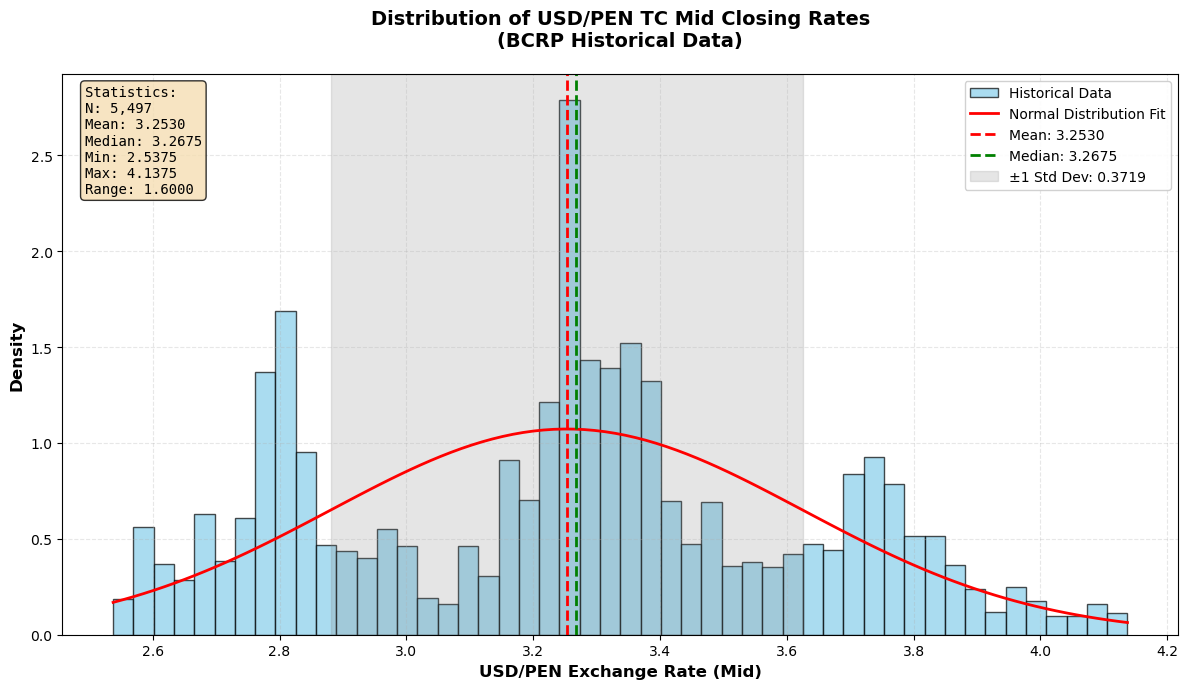

Distribution Statistics for TC_Mid
Observations: 5,497
Mean:         3.2530
Median:       3.2675
Std Dev:      0.3719
Variance:     0.138331
Skewness:     0.0726
Kurtosis:     -0.7859
Min:          2.5375
Max:          4.1375
Range:        1.6000

Percentiles:
  1%:  2.5790
  5%:  2.6715
 25%:  2.9085
 50%:  3.2675
 75%:  3.4868
 95%:  3.8530
 99%:  4.0636

Normality Test (D'Agostino-Pearson):
  Test Statistic: 438.4636
  P-value:        0.000000
  Result: Data is NOT normally distributed (p < 0.05)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def plot_fx_distribution(df_fx):
    """
    Plots the distribution of TC_Mid FX rates with a fitted normal curve.
    """
    
    # Remove NaN values
    data = df_fx['TC_Mid'].dropna()
    
    # Calculate statistics
    mean = data.mean()
    std = data.std()
    median = data.median()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot histogram
    n, bins, patches = ax.hist(data, bins=50, density=True, alpha=0.7, 
                                color='skyblue', edgecolor='black', label='Historical Data')
    
    # Fit and plot normal distribution
    x = np.linspace(data.min(), data.max(), 100)
    pdf = stats.norm.pdf(x, mean, std)
    ax.plot(x, pdf, 'r-', linewidth=2, label='Normal Distribution Fit')
    
    # Add vertical lines for mean and median
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.4f}')
    ax.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.4f}')
    
    # Add shaded area for 1 standard deviation
    ax.axvspan(mean - std, mean + std, alpha=0.2, color='gray', label=f'±1 Std Dev: {std:.4f}')
    
    # Labels and title
    ax.set_xlabel('USD/PEN Exchange Rate (Mid)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of USD/PEN TC Mid Closing Rates\n(BCRP Historical Data)', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Legend
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    # Add statistics box
    textstr = f'Statistics:\n'
    textstr += f'N: {len(data):,}\n'
    textstr += f'Mean: {mean:.4f}\n'
    textstr += f'Median: {median:.4f}\n'
    # textstr += f'Std Dev: {std:.4f}\n'
    textstr += f'Min: {data.min():.4f}\n'
    textstr += f'Max: {data.max():.4f}\n'
    textstr += f'Range: {data.max() - data.min():.4f}'
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print("="*60)
    print("Distribution Statistics for TC_Mid")
    print("="*60)
    print(f"Observations: {len(data):,}")
    print(f"Mean:         {mean:.4f}")
    print(f"Median:       {median:.4f}")
    print(f"Std Dev:      {std:.4f}")
    print(f"Variance:     {std**2:.6f}")
    print(f"Skewness:     {stats.skew(data):.4f}")
    print(f"Kurtosis:     {stats.kurtosis(data):.4f}")
    print(f"Min:          {data.min():.4f}")
    print(f"Max:          {data.max():.4f}")
    print(f"Range:        {data.max() - data.min():.4f}")
    print(f"\nPercentiles:")
    print(f"  1%:  {np.percentile(data, 1):.4f}")
    print(f"  5%:  {np.percentile(data, 5):.4f}")
    print(f" 25%:  {np.percentile(data, 25):.4f}")
    print(f" 50%:  {np.percentile(data, 50):.4f}")
    print(f" 75%:  {np.percentile(data, 75):.4f}")
    print(f" 95%:  {np.percentile(data, 95):.4f}")
    print(f" 99%:  {np.percentile(data, 99):.4f}")
    
    # Normality test
    stat, p_value = stats.normaltest(data)
    print(f"\nNormality Test (D'Agostino-Pearson):")
    print(f"  Test Statistic: {stat:.4f}")
    print(f"  P-value:        {p_value:.6f}")
    if p_value < 0.05:
        print(f"  Result: Data is NOT normally distributed (p < 0.05)")
    else:
        print(f"  Result: Data appears normally distributed (p ≥ 0.05)")

# Run the visualization
plot_fx_distribution(df_fx)

In [3]:
import pandas as pd
import numpy as np

def calculate_gfv(df_fx):
    """
    Calculate GFV (Golden Fibonacci Value) based on 252-day rolling high/low.
    
    GFV = 0.618 * (252d high / 252d low) + (252d high / 252d low) / 2
    
    Parameters:
    df_fx: DataFrame with columns 'Date' and 'TC_Mid'
    
    Returns:
    df_fx: DataFrame with added 'GFV' column
    """
    
    # Make a copy to avoid modifying the original
    df = df_fx.copy()
    
    # Ensure data is sorted by date
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Calculate 252-day rolling high and low
    window = 252
    df['rolling_252d_high'] = df['TC_Mid'].rolling(window=window, min_periods=window).max()
    df['rolling_252d_low'] = df['TC_Mid'].rolling(window=window, min_periods=window).min()
    
    # Calculate the ratio (high / low)
    df['hl_ratio'] = df['rolling_252d_high'] / df['rolling_252d_low']
    
    # Calculate GFV using the formula
    df['GFV'] = (0.618 * df['hl_ratio']) * (df['rolling_252d_high'] + df['rolling_252d_low']/ 2)
    
    # Alternative (simplified): GFV = hl_ratio * (0.618 + 0.5) = hl_ratio * 1.118
    # df['GFV'] = df['hl_ratio'] * 1.118
    
    # Drop intermediate calculation columns (optional - keep them for debugging)
    # df = df.drop(columns=['rolling_252d_high', 'rolling_252d_low', 'hl_ratio'])
    
    # Print summary
    print("="*70)
    print("GFV Calculation Summary")
    print("="*70)
    print(f"Total observations: {len(df):,}")
    print(f"GFV values computed: {df['GFV'].notna().sum():,}")
    print(f"Missing GFV values (first 251 days): {df['GFV'].isna().sum():,}")
    print(f"\nGFV Statistics:")
    print(f"  Mean:   {df['GFV'].mean():.6f}")
    print(f"  Median: {df['GFV'].median():.6f}")
    print(f"  Std:    {df['GFV'].std():.6f}")
    print(f"  Min:    {df['GFV'].min():.6f}")
    print(f"  Max:    {df['GFV'].max():.6f}")
    
    print(f"\nFirst valid GFV date: {df[df['GFV'].notna()]['Date'].min()}")
    print(f"Last GFV date: {df[df['GFV'].notna()]['Date'].max()}")
    
    print("\nSample data (most recent 10 rows):")
    print(df[['Date', 'TC_Mid', 'rolling_252d_high', 'rolling_252d_low', 
              'hl_ratio', 'GFV']].tail(10).to_string(index=False))
    
    return df

# Calculate GFV and update df_fx
df_fx = calculate_gfv(df_fx)

# Display the result
print("\n" + "="*70)
print("Updated DataFrame with GFV column")
print("="*70)
print(df_fx.head(260))  # Show first 260 rows to see where GFV starts appearing

GFV Calculation Summary
Total observations: 5,497
GFV values computed: 5,246
Missing GFV values (first 251 days): 251

GFV Statistics:
  Mean:   3.330351
  Median: 3.313417
  Std:    0.430206
  Min:    2.598143
  Max:    4.241517

First valid GFV date: 2005-01-18 00:00:00
Last GFV date: 2026-02-13 00:00:00

Sample data (most recent 10 rows):
      Date  TC_Mid  rolling_252d_high  rolling_252d_low  hl_ratio      GFV
2026-02-02  3.3660              3.747            3.3455  1.120012 3.751374
2026-02-03  3.3615              3.747            3.3455  1.120012 3.751374
2026-02-04  3.3615              3.747            3.3455  1.120012 3.751374
2026-02-05  3.3665              3.747            3.3455  1.120012 3.751374
2026-02-06  3.3585              3.747            3.3455  1.120012 3.751374
2026-02-09  3.3560              3.747            3.3455  1.120012 3.751374
2026-02-10  3.3575              3.747            3.3455  1.120012 3.751374
2026-02-11  3.3545              3.747            3.3455 

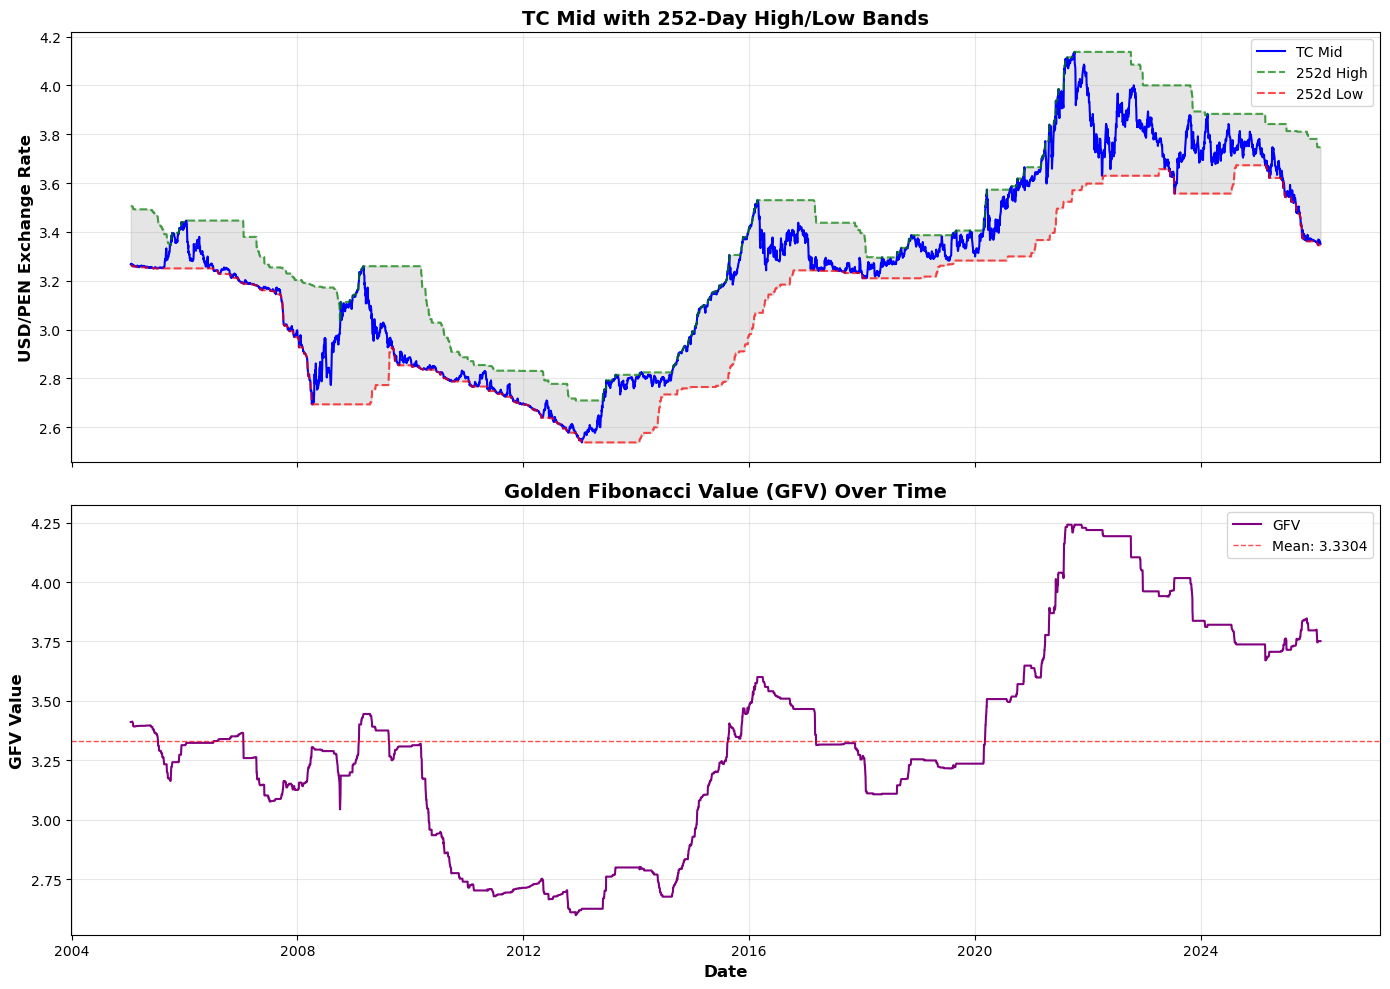

In [4]:
import matplotlib.pyplot as plt

def plot_gfv_analysis(df_fx):
    """
    Plot TC_Mid and GFV over time.
    """
    
    # Filter to non-null GFV values
    df_plot = df_fx[df_fx['GFV'].notna()].copy()
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Plot 1: TC_Mid with 252d High/Low bands
    ax1 = axes[0]
    ax1.plot(df_plot['Date'], df_plot['TC_Mid'], label='TC Mid', color='blue', linewidth=1.5)
    
    if 'rolling_252d_high' in df_plot.columns:
        ax1.plot(df_plot['Date'], df_plot['rolling_252d_high'], 
                 label='252d High', color='green', linestyle='--', alpha=0.7)
        ax1.plot(df_plot['Date'], df_plot['rolling_252d_low'], 
                 label='252d Low', color='red', linestyle='--', alpha=0.7)
        ax1.fill_between(df_plot['Date'], df_plot['rolling_252d_low'], 
                         df_plot['rolling_252d_high'], alpha=0.2, color='gray')
    
    ax1.set_ylabel('USD/PEN Exchange Rate', fontsize=12, fontweight='bold')
    ax1.set_title('TC Mid with 252-Day High/Low Bands', fontsize=14, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: GFV
    ax2 = axes[1]
    ax2.plot(df_plot['Date'], df_plot['GFV'], label='GFV', color='purple', linewidth=1.5)
    ax2.axhline(df_plot['GFV'].mean(), color='red', linestyle='--', 
                linewidth=1, alpha=0.7, label=f"Mean: {df_plot['GFV'].mean():.4f}")
    ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax2.set_ylabel('GFV Value', fontsize=12, fontweight='bold')
    ax2.set_title('Golden Fibonacci Value (GFV) Over Time', fontsize=14, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot the analysis
plot_gfv_analysis(df_fx)

Found 90 intersection points
Found 104 std dev bands intersection points


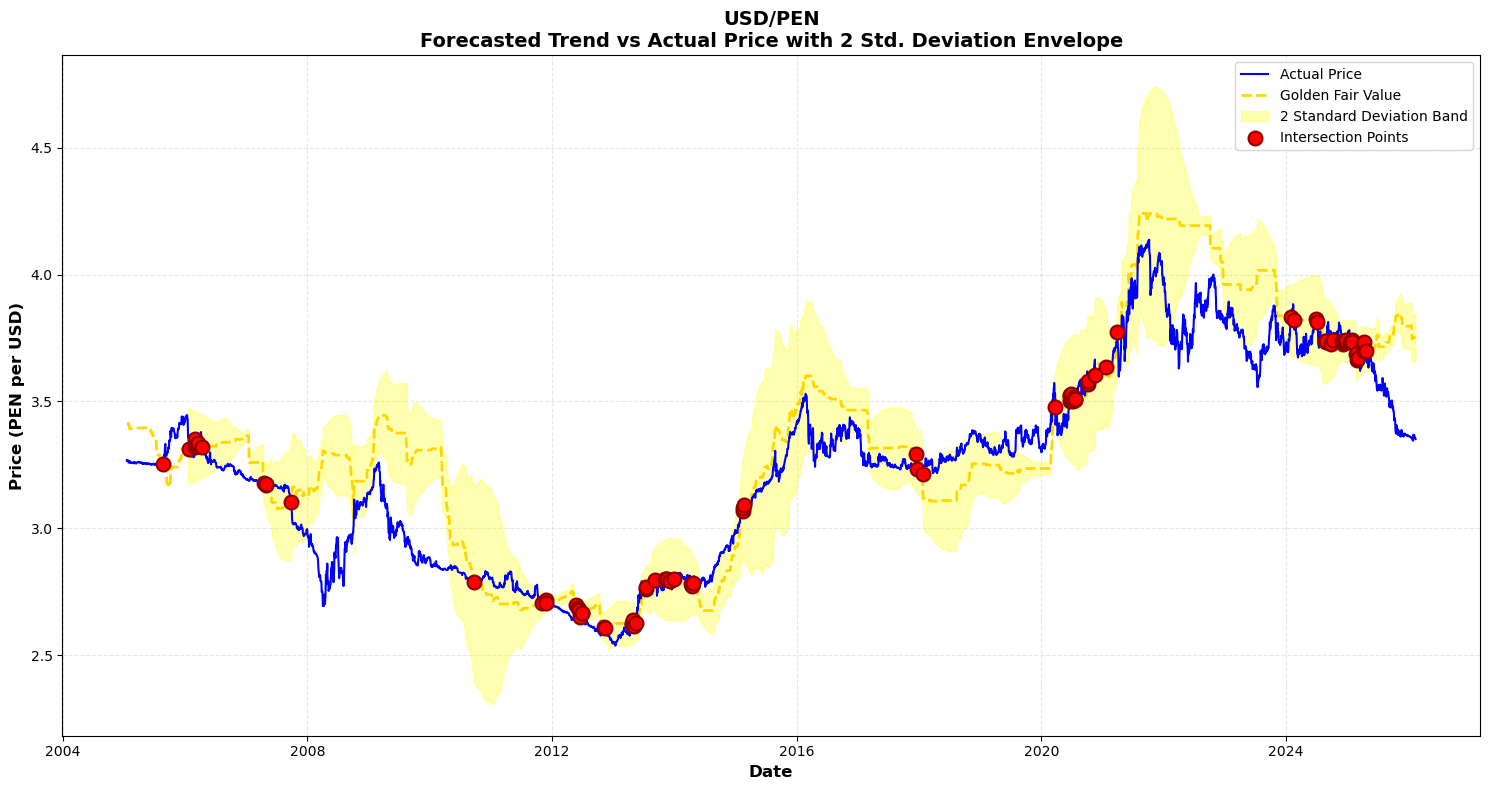


Intersection Points:
      Date  TC_Mid      GFV
2005-08-19  3.2545 3.252446
2006-01-26  3.3145 3.323337
2006-03-02  3.3505 3.323337
2006-03-03  3.3195 3.323337
2006-03-06  3.3280 3.323337
2006-03-16  3.3230 3.323337
2006-03-17  3.3355 3.323337
2006-04-12  3.3195 3.323337
2007-04-16  3.1795 3.169106
2007-04-27  3.1710 3.173247
2007-04-30  3.1730 3.150046
2007-09-26  3.1040 3.112033
2010-09-22  2.7895 2.775929
2011-11-03  2.7045 2.706972
2011-11-25  2.7175 2.710026
2011-11-28  2.7075 2.710026
2012-05-23  2.6965 2.687757
2012-06-06  2.6865 2.687757
2012-06-13  2.6780 2.665170
2012-06-15  2.6500 2.665170
2012-06-27  2.6675 2.666198
2012-06-28  2.6645 2.666198
2012-11-09  2.6125 2.610342
2012-11-13  2.6065 2.610342
2013-04-24  2.6255 2.625208
2013-04-25  2.6185 2.625208
2013-04-26  2.6385 2.625208
2013-05-06  2.6135 2.625208
2013-05-15  2.6285 2.625208
2013-07-17  2.7600 2.760405
2013-07-18  2.7690 2.760405
2013-09-09  2.7970 2.798915
2013-11-08  2.8005 2.798915
2013-11-14  2.7985 2.79891

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# CONFIGURATION FLAGS - CHANGE THESE
# =============================================================================
SHOW_INTERSECTIONS = True   # True/False: Show red dots at crossings
SHOW_LABELS = False          # True/False: Show date/value labels at crossings
# =============================================================================

# Prepare data
df = df_fx[df_fx['GFV'].notna()].copy()

# Calculate bands
df['GFV_std'] = df['GFV'].rolling(window=252, min_periods=252).std()
df['GFV_upper'] = df['GFV'] + 2 * df['GFV_std']
df['GFV_lower'] = df['GFV'] - 2 * df['GFV_std']

# Find crossings
df['crosses'] = ((df['TC_Mid'] > df['GFV']) != (df['TC_Mid'].shift(1) > df['GFV'].shift(1)))
crossings = df[df['crosses'] == True]

# SD Crossings

df['usdcrosses'] = ((df['TC_Mid'] > df['GFV_upper']) != (df['TC_Mid'].shift(1) > df['GFV_upper'].shift(1)))
df['lsdcrosses'] = ((df['TC_Mid'] > df['GFV_lower']) != (df['TC_Mid'].shift(1) > df['GFV_lower'].shift(1)))
df['sdcrosses'] = df['usdcrosses']+df['lsdcrosses']
sdcrossings = df[df['sdcrosses'] == True]


print(f"Found {len(crossings)} intersection points")
print(f"Found {len(sdcrossings)} std dev bands intersection points")
# Create plot
fig, ax = plt.subplots(figsize=(15, 8))

# Main lines
ax.plot(df['Date'], df['TC_Mid'], 'b-', linewidth=1.5, label='Actual Price', zorder=3)
ax.plot(df['Date'], df['GFV'], color='gold', linewidth=2, linestyle='--', 
        label='Golden Fair Value', zorder=2)
ax.fill_between(df['Date'], df['GFV_lower'], df['GFV_upper'], 
                 color='yellow', alpha=0.3, label='2 Standard Deviation Band', zorder=1)

# Intersection points (controlled by flags)
if SHOW_INTERSECTIONS and len(crossings) > 0:
    ax.scatter(crossings['Date'], crossings['TC_Mid'], color='red', s=100, 
              zorder=5, edgecolors='darkred', linewidths=1.5, label='Intersection Points')
    
    if SHOW_LABELS:
        for idx, row in crossings.iterrows():
            date_str = row['Date'].strftime('%Y-%m-%d')
            value_str = f"{row['TC_Mid']:.3f}"
            xytext = (0, 15 if idx % 2 == 0 else -15)
            va = 'bottom' if idx % 2 == 0 else 'top'
            
            ax.annotate(f"{date_str}\n{value_str}",
                       xy=(row['Date'], row['TC_Mid']),
                       xytext=xytext,
                       textcoords='offset points',
                       fontsize=8,
                       ha='center',
                       va=va,
                       bbox=dict(boxstyle='round', fc='white', ec='red', alpha=0.8),
                       arrowprops=dict(arrowstyle='->', color='red', lw=1))

# Formatting
ax.set_title('USD/PEN\nForecasted Trend vs Actual Price with 2 Std. Deviation Envelope', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (PEN per USD)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary
if SHOW_INTERSECTIONS and len(crossings) > 0:
    print("\nIntersection Points:")
    print(crossings[['Date', 'TC_Mid', 'GFV']].to_string(index=False))

Actual Prices - Mean: 3.2457, Std: 0.3788
GFV Values    - Mean: 3.3304, Std: 0.4302


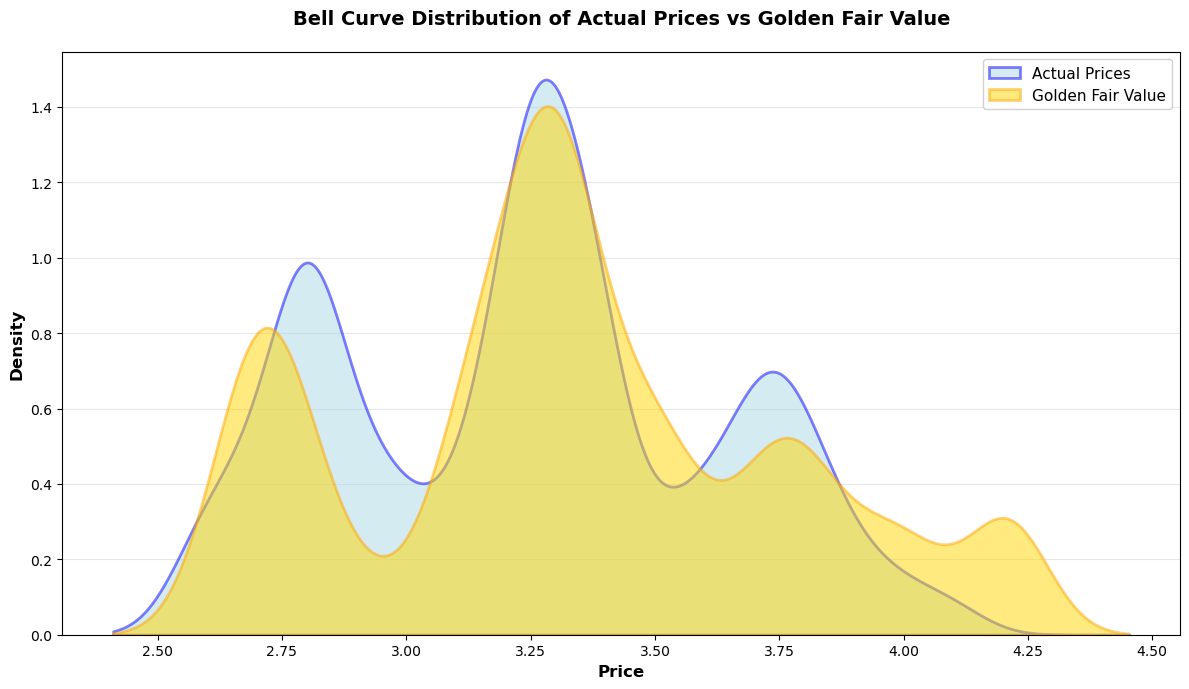


Distribution Comparison
Metric                 Actual Prices             GFV
------------------------------------------------------------
Mean                          3.2457          3.3304
Median                        3.2585          3.3134
Std Dev                       0.3788          0.4302
Min                           2.5375          2.5981
Max                           4.1375          4.2415
Skewness                      0.1241          0.2392
Kurtosis                     -0.8400         -0.5803


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde

def plot_dual_distribution(df_fx):
    """
    Plot overlapping bell curve distributions for TC_Mid and GFV.
    Replicates the MSFT distribution chart style.
    """
    
    # Filter to rows with both TC_Mid and GFV
    df = df_fx[['TC_Mid', 'GFV']].dropna()
    
    # Get the data
    actual_prices = df['TC_Mid'].values
    gfv_values = df['GFV'].values
    
    print(f"Actual Prices - Mean: {actual_prices.mean():.4f}, Std: {actual_prices.std():.4f}")
    print(f"GFV Values    - Mean: {gfv_values.mean():.4f}, Std: {gfv_values.std():.4f}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Create kernel density estimates
    kde_actual = gaussian_kde(actual_prices)
    kde_gfv = gaussian_kde(gfv_values)
    
    # Create x-axis range for plotting (from min to max of both datasets)
    x_min = min(actual_prices.min(), gfv_values.min()) * 0.95
    x_max = max(actual_prices.max(), gfv_values.max()) * 1.05
    x_range = np.linspace(x_min, x_max, 1000)
    
    # Calculate density values
    density_actual = kde_actual(x_range)
    density_gfv = kde_gfv(x_range)
    
    # Plot filled curves
    ax.fill_between(x_range, density_actual, alpha=0.5, color='lightblue', 
                     edgecolor='blue', linewidth=2, label='Actual Prices')
    ax.fill_between(x_range, density_gfv, alpha=0.5, color='gold', 
                     edgecolor='orange', linewidth=2, label='Golden Fair Value')
    
    # Labels and title
    ax.set_xlabel('Price', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title('Bell Curve Distribution of Actual Prices vs Golden Fair Value', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Legend
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    
    # Grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Set y-axis to start at 0
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics comparison
    print("\n" + "="*60)
    print("Distribution Comparison")
    print("="*60)
    print(f"{'Metric':<20} {'Actual Prices':>15} {'GFV':>15}")
    print("-"*60)
    print(f"{'Mean':<20} {actual_prices.mean():>15.4f} {gfv_values.mean():>15.4f}")
    print(f"{'Median':<20} {np.median(actual_prices):>15.4f} {np.median(gfv_values):>15.4f}")
    print(f"{'Std Dev':<20} {actual_prices.std():>15.4f} {gfv_values.std():>15.4f}")
    print(f"{'Min':<20} {actual_prices.min():>15.4f} {gfv_values.min():>15.4f}")
    print(f"{'Max':<20} {actual_prices.max():>15.4f} {gfv_values.max():>15.4f}")
    print(f"{'Skewness':<20} {stats.skew(actual_prices):>15.4f} {stats.skew(gfv_values):>15.4f}")
    print(f"{'Kurtosis':<20} {stats.kurtosis(actual_prices):>15.4f} {stats.kurtosis(gfv_values):>15.4f}")

# Run the plot
plot_dual_distribution(df_fx)

STATISTICAL SIGNIFICANCE TESTS FOR GFV INDICATOR

Dataset: USD/PEN Exchange Rate
Observations: 5,246
Period: 2004-01-19 00:00:00 to 2026-02-13 00:00:00

TEST 1: T-TEST - Comparing Means of GFV vs Actual Price

Descriptive Statistics:
  TC_Mid Mean:  3.245736
  GFV Mean:     3.330351
  Difference:   0.084615 (2.61%)

T-Test Results:
  T-Statistic:  10.6916
  P-Value:      0.0000000000
  P-Value:      1.53e-26 (scientific notation)

  Decision (α=0.05):
  ✓ REJECT NULL HYPOTHESIS
  → GFV captures a statistically distinct 'fair value' level
  → GFV mean is significantly different from actual price
  → This supports mean reversion: prices deviate from GFV and may return to it

TEST 2: CHI-SQUARE TEST - GFV Deviation vs Market Trends

Contingency Table (Deviation Category vs Price Direction):
price_direction     Down   Up
deviation_category           
Large Undervalued    639  501
Undervalued          768  570
Fair                 926  854
Overvalued           444  417
Large Overvalued     

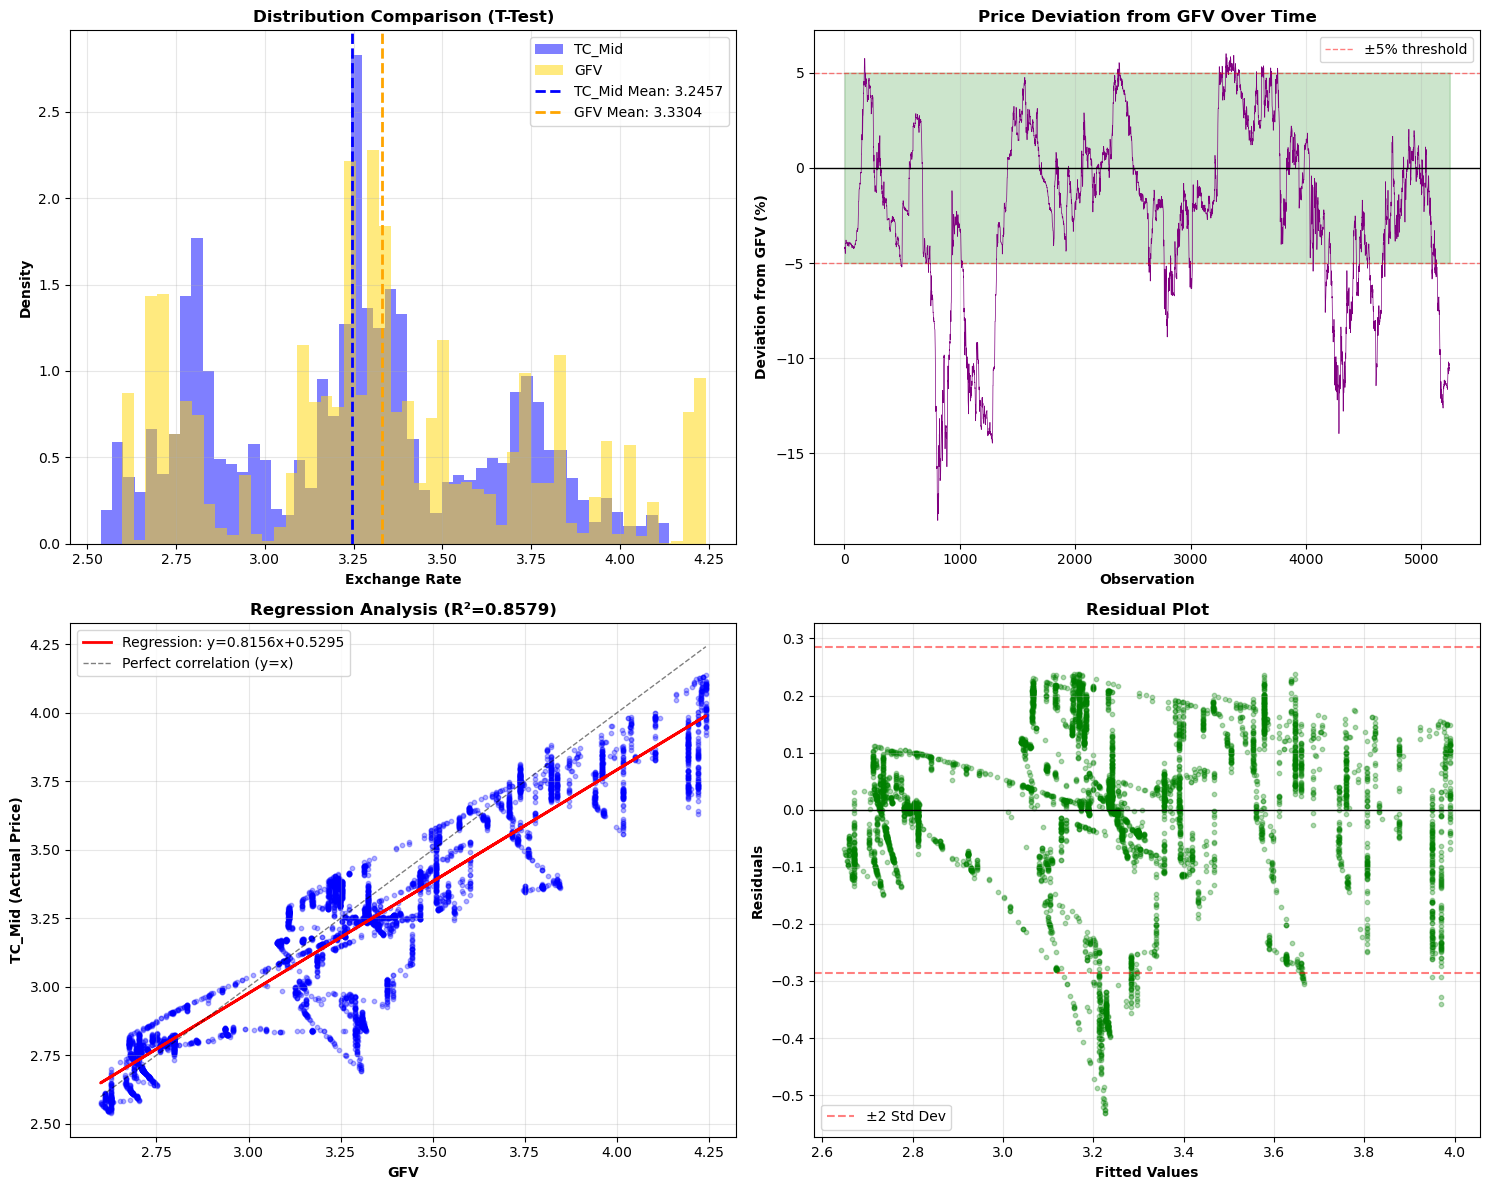


OVERALL SUMMARY & INTERPRETATION

Tests Passed: 3/3

📊 PRACTITIONER'S INTERPRETATION:

1. Mean Reversion Evidence:
   ✓ GFV identifies a distinct 'fair value' level
   ✓ Actual prices deviate from this level by 2.61% on average
   → Use GFV as a target for mean reversion trades

2. Predictive Power:
   ✓ Large deviations from GFV predict price reversals
   → Trade when price > GFV + 2σ (overbought) or < GFV - 2σ (oversold)

3. Explanatory Power:
   ✓ GFV explains 85.8% of price movements (strong)
   → GFV is a reliable indicator for this currency pair

4. Trading Implications:
   ✓ GFV is statistically valid for USD/PEN
   ✓ Use GFV for:
     • Identifying overbought/oversold conditions
     • Setting profit targets during corrections
     • Risk management (exit when deviation > 2σ)


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def perform_gfv_statistical_tests(df_fx):
    """
    Perform comprehensive statistical significance tests on GFV indicator.
    Tests: T-Test, Chi-Square, and Regression Analysis
    
    Parameters:
    df_fx: DataFrame with 'Date', 'TC_Mid', and 'GFV' columns
    
    Returns:
    Dictionary with all test results
    """
    
    # Clean data - remove NaN values
    df = df_fx[['TC_Mid', 'GFV']].dropna()
    
    print("="*80)
    print("STATISTICAL SIGNIFICANCE TESTS FOR GFV INDICATOR")
    print("="*80)
    print(f"\nDataset: USD/PEN Exchange Rate")
    print(f"Observations: {len(df):,}")
    print(f"Period: {df_fx['Date'].min()} to {df_fx['Date'].max()}")
    
    # =========================================================================
    # TEST 1: T-TEST (Comparing Means)
    # =========================================================================
    print("\n" + "="*80)
    print("TEST 1: T-TEST - Comparing Means of GFV vs Actual Price")
    print("="*80)
    
    # Calculate means
    mean_price = df['TC_Mid'].mean()
    mean_gfv = df['GFV'].mean()
    
    # Perform two-sample t-test
    t_statistic, p_value_ttest = stats.ttest_ind(df['GFV'], df['TC_Mid'])
    
    print(f"\nDescriptive Statistics:")
    print(f"  TC_Mid Mean:  {mean_price:.6f}")
    print(f"  GFV Mean:     {mean_gfv:.6f}")
    print(f"  Difference:   {mean_gfv - mean_price:.6f} ({((mean_gfv - mean_price)/mean_price)*100:.2f}%)")
    
    print(f"\nT-Test Results:")
    print(f"  T-Statistic:  {t_statistic:.4f}")
    print(f"  P-Value:      {p_value_ttest:.10f}")
    
    if p_value_ttest < 0.001:
        print(f"  P-Value:      {p_value_ttest:.2e} (scientific notation)")
    
    print(f"\n  Decision (α=0.05):")
    if p_value_ttest < 0.05:
        print(f"  ✓ REJECT NULL HYPOTHESIS")
        print(f"  → GFV captures a statistically distinct 'fair value' level")
        print(f"  → GFV mean is significantly different from actual price")
        print(f"  → This supports mean reversion: prices deviate from GFV and may return to it")
    else:
        print(f"  ✗ FAIL TO REJECT NULL HYPOTHESIS")
        print(f"  → GFV does not capture a distinct fair value")
        print(f"  → GFV simply follows the price")
    
    # =========================================================================
    # TEST 2: CHI-SQUARE TEST (Relationship between deviations and trends)
    # =========================================================================
    print("\n" + "="*80)
    print("TEST 2: CHI-SQUARE TEST - GFV Deviation vs Market Trends")
    print("="*80)
    
    # Calculate price deviations from GFV
    df_test = df.copy()
    df_test['deviation'] = ((df_test['TC_Mid'] - df_test['GFV']) / df_test['GFV']) * 100
    
    # Categorize deviations
    df_test['deviation_category'] = pd.cut(
        df_test['deviation'],
        bins=[-np.inf, -5, -2, 2, 5, np.inf],
        labels=['Large Undervalued', 'Undervalued', 'Fair', 'Overvalued', 'Large Overvalued']
    )
    
    # Calculate price direction (up/down from previous day)
    df_test['price_direction'] = np.where(
        df_test['TC_Mid'].diff() > 0, 'Up', 'Down'
    )
    
    # Create contingency table
    contingency_table = pd.crosstab(
        df_test['deviation_category'],
        df_test['price_direction']
    )
    
    print(f"\nContingency Table (Deviation Category vs Price Direction):")
    print(contingency_table)
    
    # Perform chi-square test
    chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\nChi-Square Test Results:")
    print(f"  Chi-Square Statistic: {chi2_stat:.4f}")
    print(f"  Degrees of Freedom:   {dof}")
    print(f"  P-Value:              {p_value_chi2:.10f}")
    
    if p_value_chi2 < 0.001:
        print(f"  P-Value:              {p_value_chi2:.2e} (scientific notation)")
    
    print(f"\n  Decision (α=0.05):")
    if p_value_chi2 < 0.05:
        print(f"  ✓ REJECT NULL HYPOTHESIS")
        print(f"  → Strong relationship between GFV deviation and price movements")
        print(f"  → When prices deviate from GFV, they tend to reverse direction")
        print(f"  → GFV has predictive power for mean reversion")
    else:
        print(f"  ✗ FAIL TO REJECT NULL HYPOTHESIS")
        print(f"  → No significant relationship between deviation and trends")
        print(f"  → GFV deviations don't predict price reversals")
    
    # =========================================================================
    # TEST 3: REGRESSION ANALYSIS (Linear relationship)
    # =========================================================================
    print("\n" + "="*80)
    print("TEST 3: REGRESSION ANALYSIS - GFV vs Actual Price")
    print("="*80)
    
    # Prepare data for regression
    X = df['GFV'].values.reshape(-1, 1)
    y = df['TC_Mid'].values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Get predictions
    y_pred = model.predict(X)
    
    # Calculate metrics
    slope = model.coef_[0]
    intercept = model.intercept_
    r_squared = r2_score(y, y_pred)
    
    # Calculate residuals
    residuals = y - y_pred
    residual_std = np.std(residuals)
    
    # Calculate t-statistic for slope
    n = len(X)
    se_slope = residual_std / np.sqrt(np.sum((X - X.mean())**2))
    t_stat_slope = slope / se_slope
    p_value_slope = 2 * (1 - stats.t.cdf(abs(t_stat_slope), n - 2))
    
    print(f"\nRegression Model: TC_Mid = {intercept:.6f} + {slope:.6f} × GFV")
    print(f"\nRegression Results:")
    print(f"  Slope (β1):           {slope:.6f}")
    print(f"  Intercept (β0):       {intercept:.6f}")
    print(f"  R-squared:            {r_squared:.6f} ({r_squared*100:.2f}%)")
    print(f"  Standard Error:       {residual_std:.6f}")
    
    print(f"\n  Slope Significance Test:")
    print(f"  T-Statistic:          {t_stat_slope:.4f}")
    print(f"  P-Value:              {p_value_slope:.10f}")
    
    if p_value_slope < 0.001:
        print(f"  P-Value:              {p_value_slope:.2e} (scientific notation)")
    
    print(f"\n  Decision (α=0.05):")
    if p_value_slope < 0.05:
        print(f"  ✓ REJECT NULL HYPOTHESIS")
        print(f"  → Statistically significant linear relationship exists")
        print(f"  → GFV explains {r_squared*100:.2f}% of price variance")
        print(f"  → Slope of {slope:.4f} shows strong tracking relationship")
    else:
        print(f"  ✗ FAIL TO REJECT NULL HYPOTHESIS")
        print(f"  → No significant linear relationship")
        print(f"  → GFV has no predictive power")
    
    # Interpretation of slope
    print(f"\n  Slope Interpretation:")
    if slope > 1.1:
        print(f"  → GFV amplifies price movements (slope > 1)")
        print(f"  → 1 unit change in GFV → {slope:.2f} units change in price")
    elif slope < 0.9:
        print(f"  → GFV dampens price movements (slope < 1)")
    else:
        print(f"  → GFV tracks price almost 1:1 (slope ≈ 1)")
    
    # =========================================================================
    # VISUALIZATION
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Distribution comparison
    ax1 = axes[0, 0]
    ax1.hist(df['TC_Mid'], bins=50, alpha=0.5, label='TC_Mid', color='blue', density=True)
    ax1.hist(df['GFV'], bins=50, alpha=0.5, label='GFV', color='gold', density=True)
    ax1.axvline(mean_price, color='blue', linestyle='--', linewidth=2, label=f'TC_Mid Mean: {mean_price:.4f}')
    ax1.axvline(mean_gfv, color='orange', linestyle='--', linewidth=2, label=f'GFV Mean: {mean_gfv:.4f}')
    ax1.set_xlabel('Exchange Rate', fontweight='bold')
    ax1.set_ylabel('Density', fontweight='bold')
    ax1.set_title('Distribution Comparison (T-Test)', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Deviation over time
    ax2 = axes[0, 1]
    deviation_series = ((df['TC_Mid'] - df['GFV']) / df['GFV']) * 100
    ax2.plot(deviation_series.values, linewidth=0.5, color='purple')
    ax2.axhline(0, color='black', linestyle='-', linewidth=1)
    ax2.axhline(5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='±5% threshold')
    ax2.axhline(-5, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax2.fill_between(range(len(deviation_series)), -5, 5, alpha=0.2, color='green')
    ax2.set_xlabel('Observation', fontweight='bold')
    ax2.set_ylabel('Deviation from GFV (%)', fontweight='bold')
    ax2.set_title('Price Deviation from GFV Over Time', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Scatter plot with regression line
    ax3 = axes[1, 0]
    ax3.scatter(df['GFV'], df['TC_Mid'], alpha=0.3, s=10, color='blue')
    ax3.plot(df['GFV'], y_pred, color='red', linewidth=2, label=f'Regression: y={slope:.4f}x+{intercept:.4f}')
    ax3.plot([df['GFV'].min(), df['GFV'].max()], [df['GFV'].min(), df['GFV'].max()], 
             'k--', linewidth=1, alpha=0.5, label='Perfect correlation (y=x)')
    ax3.set_xlabel('GFV', fontweight='bold')
    ax3.set_ylabel('TC_Mid (Actual Price)', fontweight='bold')
    ax3.set_title(f'Regression Analysis (R²={r_squared:.4f})', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Residuals
    ax4 = axes[1, 1]
    ax4.scatter(y_pred, residuals, alpha=0.3, s=10, color='green')
    ax4.axhline(0, color='black', linestyle='-', linewidth=1)
    ax4.axhline(2*residual_std, color='red', linestyle='--', alpha=0.5, label='±2 Std Dev')
    ax4.axhline(-2*residual_std, color='red', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Fitted Values', fontweight='bold')
    ax4.set_ylabel('Residuals', fontweight='bold')
    ax4.set_title('Residual Plot', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # SUMMARY
    # =========================================================================
    print("\n" + "="*80)
    print("OVERALL SUMMARY & INTERPRETATION")
    print("="*80)
    
    tests_passed = 0
    if p_value_ttest < 0.05:
        tests_passed += 1
    if p_value_chi2 < 0.05:
        tests_passed += 1
    if p_value_slope < 0.05:
        tests_passed += 1
    
    print(f"\nTests Passed: {tests_passed}/3")
    
    print(f"\n📊 PRACTITIONER'S INTERPRETATION:")
    print(f"\n1. Mean Reversion Evidence:")
    if p_value_ttest < 0.05:
        print(f"   ✓ GFV identifies a distinct 'fair value' level")
        print(f"   ✓ Actual prices deviate from this level by {abs((mean_gfv - mean_price)/mean_price)*100:.2f}% on average")
        print(f"   → Use GFV as a target for mean reversion trades")
    else:
        print(f"   ✗ GFV does not identify a distinct fair value")
    
    print(f"\n2. Predictive Power:")
    if p_value_chi2 < 0.05:
        print(f"   ✓ Large deviations from GFV predict price reversals")
        print(f"   → Trade when price > GFV + 2σ (overbought) or < GFV - 2σ (oversold)")
    else:
        print(f"   ✗ Deviations don't predict reversals")
    
    print(f"\n3. Explanatory Power:")
    if r_squared > 0.7:
        print(f"   ✓ GFV explains {r_squared*100:.1f}% of price movements (strong)")
        print(f"   → GFV is a reliable indicator for this currency pair")
    elif r_squared > 0.4:
        print(f"   ⚠ GFV explains {r_squared*100:.1f}% of price movements (moderate)")
    else:
        print(f"   ✗ GFV explains only {r_squared*100:.1f}% of price movements (weak)")
    
    print(f"\n4. Trading Implications:")
    if tests_passed >= 2:
        print(f"   ✓ GFV is statistically valid for USD/PEN")
        print(f"   ✓ Use GFV for:")
        print(f"     • Identifying overbought/oversold conditions")
        print(f"     • Setting profit targets during corrections")
        print(f"     • Risk management (exit when deviation > 2σ)")
    else:
        print(f"   ⚠ GFV shows limited statistical significance")
        print(f"   → Use with caution or combine with other indicators")
    
    # Return results dictionary
    results = {
        'ttest': {
            'statistic': t_statistic,
            'pvalue': p_value_ttest,
            'mean_price': mean_price,
            'mean_gfv': mean_gfv
        },
        'chi2': {
            'statistic': chi2_stat,
            'pvalue': p_value_chi2,
            'dof': dof,
            'contingency_table': contingency_table
        },
        'regression': {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_squared,
            'pvalue_slope': p_value_slope
        }
    }
    
    return results

# Run the complete statistical analysis
results = perform_gfv_statistical_tests(df_fx)

In [ ]:
# CORRECTED MINIMAL ROBUST VALIDATION FOR PRACTITIONERS
import statsmodels.api as sm
import pandas as pd

# Fix: Drop NaNs from BOTH columns together, then align indices
df_clean = df_fx[['TC_Mid', 'GFV']].dropna().reset_index(drop=True)

# Now create X and y from the cleaned dataframe
y = df_clean['TC_Mid']
X = sm.add_constant(df_clean['GFV'])

# 1. Basic OLS regression
model_ols = sm.OLS(y, X).fit()

# 2. Robust regression (corrects autocorrelation + heteroskedasticity)
model_robust = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

# 3. Compare results
print("="*60)
print("OLS vs ROBUST STANDARD ERRORS COMPARISON")
print("="*60)
print(f"\nSample size: {len(df_clean):,} observations")
print(f"\n{'Metric':<30} {'OLS':<15} {'Robust (HAC)':<15}")
print("-"*60)
print(f"{'Slope (β1)':<30} {model_ols.params['GFV']:<15.6f} {model_robust.params['GFV']:<15.6f}")
print(f"{'Std Error':<30} {model_ols.bse['GFV']:<15.6f} {model_robust.bse['GFV']:<15.6f}")
print(f"{'T-statistic':<30} {model_ols.tvalues['GFV']:<15.4f} {model_robust.tvalues['GFV']:<15.4f}")
print(f"{'P-value':<30} {model_ols.pvalues['GFV']:<15.2e} {model_robust.pvalues['GFV']:<15.2e}")
print(f"{'R-squared':<30} {model_ols.rsquared:<15.6f} {model_robust.rsquared:<15.6f}")

# 4. Decision rule
print("\n" + "="*60)
print("SIGNAL VALIDATION DECISION")
print("="*60)

ols_sig = model_ols.pvalues['GFV'] < 0.05
robust_sig = model_robust.pvalues['GFV'] < 0.05

if robust_sig:
    print(f"✅ Signal is VALID (robust p-value = {model_robust.pvalues['GFV']:.2e})")
    print(f"   → GFV has statistically significant relationship with USD/PEN")
    print(f"   → SAFE TO USE for trading signals")
    print(f"   → R² = {model_robust.rsquared:.4f} ({model_robust.rsquared*100:.2f}% of variance explained)")
else:
    print(f"❌ Signal is NOT VALID (robust p-value = {model_robust.pvalues['GFV']:.2e})")
    print(f"   → GFV does NOT have significant relationship after robust correction")
    print(f"   → DO NOT USE for trading")

if ols_sig and not robust_sig:
    print(f"\n⚠️  WARNING: OLS was significant but robust SE is not!")
    print(f"   → This means the original significance was SPURIOUS")
    print(f"   → Caused by autocorrelation/heteroskedasticity in residuals")
    print(f"   → Original standard errors were too small (overly optimistic)")

OLS vs ROBUST STANDARD ERRORS COMPARISON

Sample size: 5,245 observations

Metric                         OLS             Robust (HAC)   
------------------------------------------------------------
Slope (β1)                     0.815699        0.815699       
Std Error                      0.004583        0.008586       
T-statistic                    177.9688        94.9990        
P-value                        0.00e+00        0.00e+00       
R-squared                      0.857974        0.857974       

SIGNAL VALIDATION DECISION
✅ Signal is VALID (robust p-value = 0.00e+00)
   → GFV has statistically significant relationship with USD/PEN
   → SAFE TO USE for trading signals
   → R² = 0.8580 (85.80% of variance explained)


ENHANCED PREDICTIVE MODELING: GFV FEATURE IMPORTANCE
Testing if GFV improves ML model performance for USD/PEN prediction

STEP 1: DATA PREPARATION

Total observations: 5,245
Date range: 2005-01-18 00:00:00 to 2026-02-12 00:00:00

Target distribution:
  Up days (1):   2,421 (46.2%)
  Down days (0): 2,822 (53.8%)

STEP 2: FEATURE ENGINEERING

Baseline features (traditional technical indicators):
  ✓ Returns (1d, 5d, 20d)
  ✓ Moving averages (10d, 50d) and ratios
  ✓ Volatility (20d)
  ✓ Price position in 20-day range

GFV features:
  ✓ GFV deviation (price vs GFV)
  ✓ GFV momentum
  ✓ GFV distance (volatility-adjusted)

Final dataset: 5,194 observations

Baseline features: 7
With GFV features: 10

STEP 3: TRAIN/TEST SPLIT (Time Series)

Training set: 3,635 obs (2005-03-31 00:00:00 to 2019-11-15 00:00:00)
Test set:     1,559 obs (2019-11-18 00:00:00 to 2026-02-11 00:00:00)

✓ Features standardized (mean=0, std=1)

STEP 4: NAIVE BAYES CLASSIFIER

Training Naive Bayes (Baseline - no GFV)...

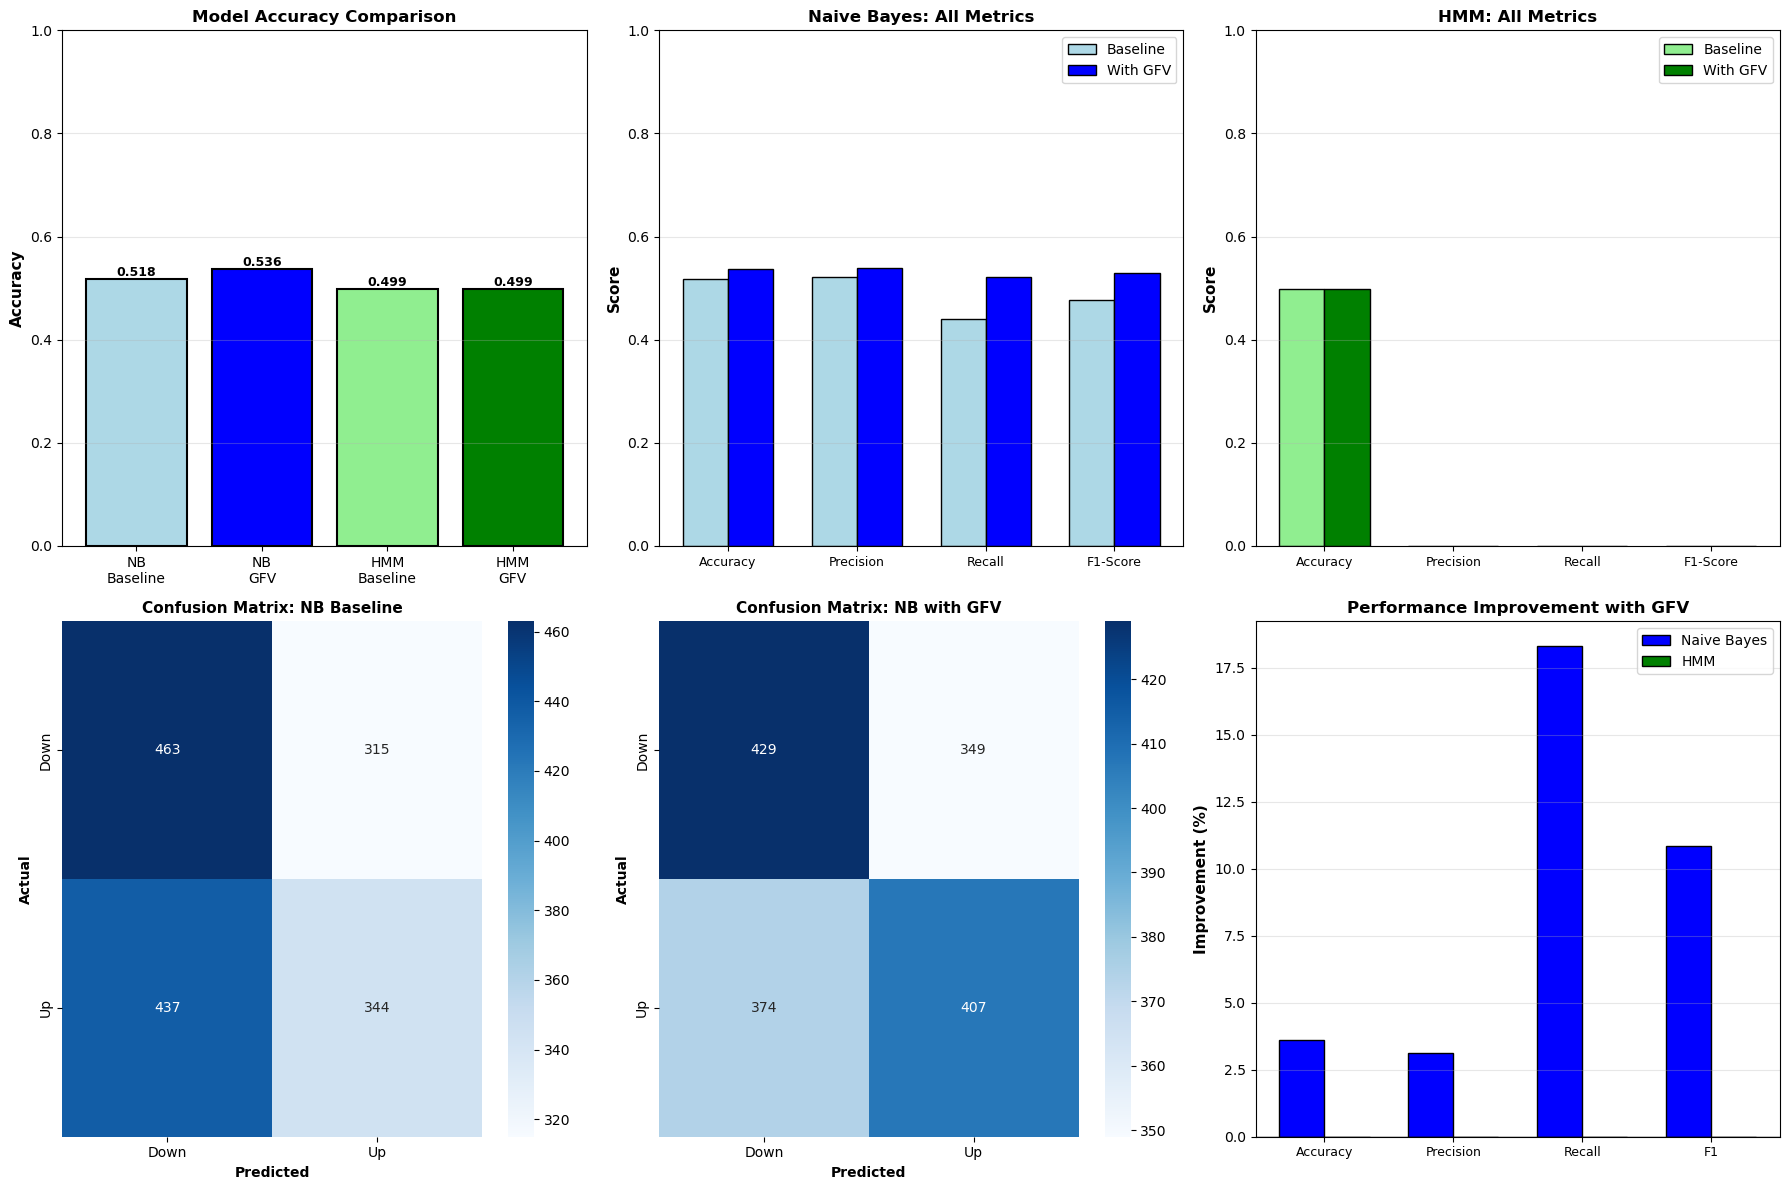


FINAL INTERPRETATION & CONCLUSIONS

📊 PREDICTIVE POWER ASSESSMENT:

1. Naive Bayes:
   ✅ GFV IMPROVES performance
   → Accuracy increased from 51.8% to 53.6%
   → Improvement: +3.59%

2. Hidden Markov Model:
   ❌ GFV does NOT improve performance
   → Accuracy decreased from 49.9% to 49.9%

3. Overall Conclusion:
   ⚠️  MIXED RESULTS
   → GFV improves some models but not others
   → May be model-specific or require tuning
   → RECOMMENDATION: Use with caution, test further

4. Best Performing Model:
   🏆 Naive Bayes with GFV
   → Accuracy: 53.6%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def enhanced_predictive_modeling(df_fx, test_size=0.3, random_state=42):
    """
    Test if GFV improves predictive power of ML models.
    
    Models tested:
    1. Naive Bayes (Baseline vs with GFV)
    2. Hidden Markov Model (Baseline vs with GFV)
    
    Target: Predict next-day price direction (Up=1, Down=0)
    
    Parameters:
    -----------
    df_fx : DataFrame with 'Date', 'TC_Mid', 'GFV'
    test_size : float, proportion for test set
    random_state : int, for reproducibility
    """
    
    print("="*80)
    print("ENHANCED PREDICTIVE MODELING: GFV FEATURE IMPORTANCE")
    print("="*80)
    print("Testing if GFV improves ML model performance for USD/PEN prediction")
    
    # =========================================================================
    # STEP 1: DATA PREPARATION
    # =========================================================================
    print("\n" + "="*80)
    print("STEP 1: DATA PREPARATION")
    print("="*80)
    
    # Clean data
    df = df_fx[['Date', 'TC_Mid', 'GFV']].dropna().copy()
    df = df.sort_values('Date').reset_index(drop=True)
    
    print(f"\nTotal observations: {len(df):,}")
    print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
    
    # Create target variable: Next day price direction
    # 1 = Up (price increases), 0 = Down (price decreases)
    df['returns'] = df['TC_Mid'].pct_change()
    df['target'] = (df['returns'].shift(-1) > 0).astype(int)  # Predict NEXT day
    
    # Remove last row (no target) and first row (no returns)
    df = df.iloc[1:-1].reset_index(drop=True)
    
    print(f"\nTarget distribution:")
    print(f"  Up days (1):   {(df['target'] == 1).sum():,} ({(df['target'] == 1).sum()/len(df)*100:.1f}%)")
    print(f"  Down days (0): {(df['target'] == 0).sum():,} ({(df['target'] == 0).sum()/len(df)*100:.1f}%)")
    
    # =========================================================================
    # STEP 2: FEATURE ENGINEERING
    # =========================================================================
    print("\n" + "="*80)
    print("STEP 2: FEATURE ENGINEERING")
    print("="*80)
    
    # BASELINE FEATURES (without GFV)
    print("\nBaseline features (traditional technical indicators):")
    
    # 1. Price momentum features
    df['returns_1d'] = df['TC_Mid'].pct_change(1)
    df['returns_5d'] = df['TC_Mid'].pct_change(5)
    df['returns_20d'] = df['TC_Mid'].pct_change(20)
    print("  ✓ Returns (1d, 5d, 20d)")
    
    # 2. Moving averages
    df['sma_10'] = df['TC_Mid'].rolling(10).mean()
    df['sma_50'] = df['TC_Mid'].rolling(50).mean()
    df['price_to_sma10'] = df['TC_Mid'] / df['sma_10'] - 1
    df['price_to_sma50'] = df['TC_Mid'] / df['sma_50'] - 1
    print("  ✓ Moving averages (10d, 50d) and ratios")
    
    # 3. Volatility
    df['volatility_20d'] = df['returns'].rolling(20).std()
    print("  ✓ Volatility (20d)")
    
    # 4. Price position in range
    df['high_20d'] = df['TC_Mid'].rolling(20).max()
    df['low_20d'] = df['TC_Mid'].rolling(20).min()
    df['price_position'] = (df['TC_Mid'] - df['low_20d']) / (df['high_20d'] - df['low_20d'])
    print("  ✓ Price position in 20-day range")
    
    # GFV-RELATED FEATURES
    print("\nGFV features:")
    
    # 5. GFV deviation
    df['gfv_deviation'] = (df['TC_Mid'] - df['GFV']) / df['GFV']
    print("  ✓ GFV deviation (price vs GFV)")
    
    # 6. GFV momentum
    df['gfv_change'] = df['GFV'].pct_change(1)
    print("  ✓ GFV momentum")
    
    # 7. Distance from GFV (standardized)
    df['gfv_distance'] = (df['TC_Mid'] - df['GFV']) / df['volatility_20d']
    print("  ✓ GFV distance (volatility-adjusted)")
    
    # Drop NaN rows from feature calculation
    df = df.dropna().reset_index(drop=True)
    
    print(f"\nFinal dataset: {len(df):,} observations")
    
    # Define feature sets
    baseline_features = [
        'returns_1d', 'returns_5d', 'returns_20d',
        'price_to_sma10', 'price_to_sma50',
        'volatility_20d', 'price_position'
    ]
    
    gfv_features = baseline_features + ['gfv_deviation', 'gfv_change', 'gfv_distance']
    
    print(f"\nBaseline features: {len(baseline_features)}")
    print(f"With GFV features: {len(gfv_features)}")
    
    # =========================================================================
    # STEP 3: TRAIN/TEST SPLIT
    # =========================================================================
    print("\n" + "="*80)
    print("STEP 3: TRAIN/TEST SPLIT (Time Series)")
    print("="*80)
    
    # Use time series split (no shuffling - preserve temporal order)
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"\nTraining set: {len(train_df):,} obs ({train_df['Date'].min()} to {train_df['Date'].max()})")
    print(f"Test set:     {len(test_df):,} obs ({test_df['Date'].min()} to {test_df['Date'].max()})")
    
    # Prepare datasets
    X_train_baseline = train_df[baseline_features].values
    X_train_gfv = train_df[gfv_features].values
    y_train = train_df['target'].values
    
    X_test_baseline = test_df[baseline_features].values
    X_test_gfv = test_df[gfv_features].values
    y_test = test_df['target'].values
    
    # Standardize features
    scaler_baseline = StandardScaler()
    X_train_baseline_scaled = scaler_baseline.fit_transform(X_train_baseline)
    X_test_baseline_scaled = scaler_baseline.transform(X_test_baseline)
    
    scaler_gfv = StandardScaler()
    X_train_gfv_scaled = scaler_gfv.fit_transform(X_train_gfv)
    X_test_gfv_scaled = scaler_gfv.transform(X_test_gfv)
    
    print(f"\n✓ Features standardized (mean=0, std=1)")
    
    # =========================================================================
    # STEP 4: NAIVE BAYES MODELS
    # =========================================================================
    print("\n" + "="*80)
    print("STEP 4: NAIVE BAYES CLASSIFIER")
    print("="*80)
    
    print("\nTraining Naive Bayes (Baseline - no GFV)...")
    nb_baseline = GaussianNB()
    nb_baseline.fit(X_train_baseline_scaled, y_train)
    y_pred_nb_baseline = nb_baseline.predict(X_test_baseline_scaled)
    
    print("Training Naive Bayes (with GFV)...")
    nb_gfv = GaussianNB()
    nb_gfv.fit(X_train_gfv_scaled, y_train)
    y_pred_nb_gfv = nb_gfv.predict(X_test_gfv_scaled)
    
    # Calculate metrics
    nb_baseline_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_nb_baseline),
        'precision': precision_score(y_test, y_pred_nb_baseline, zero_division=0),
        'recall': recall_score(y_test, y_pred_nb_baseline, zero_division=0),
        'f1': f1_score(y_test, y_pred_nb_baseline, zero_division=0)
    }
    
    nb_gfv_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_nb_gfv),
        'precision': precision_score(y_test, y_pred_nb_gfv, zero_division=0),
        'recall': recall_score(y_test, y_pred_nb_gfv, zero_division=0),
        'f1': f1_score(y_test, y_pred_nb_gfv, zero_division=0)
    }
    
    print("\n" + "-"*80)
    print("NAIVE BAYES RESULTS")
    print("-"*80)
    print(f"\n{'Metric':<15} {'Baseline':<15} {'With GFV':<15} {'Improvement':<15}")
    print("-"*80)
    
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        baseline_val = nb_baseline_metrics[metric]
        gfv_val = nb_gfv_metrics[metric]
        improvement = ((gfv_val - baseline_val) / baseline_val) * 100 if baseline_val > 0 else 0
        
        print(f"{metric.capitalize():<15} {baseline_val:<15.4f} {gfv_val:<15.4f} {improvement:>+14.2f}%")
    
    # =========================================================================
    # STEP 5: HIDDEN MARKOV MODELS
    # =========================================================================
    print("\n" + "="*80)
    print("STEP 5: HIDDEN MARKOV MODEL (HMM)")
    print("="*80)
    
    print("\nTraining HMM (Baseline - no GFV)...")
    print("  Using 2 hidden states (bull/bear market regimes)")
    
    # HMM with baseline features
    hmm_baseline = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=100,
        random_state=random_state
    )
    hmm_baseline.fit(X_train_baseline_scaled)
    
    # Predict hidden states
    hidden_states_train_baseline = hmm_baseline.predict(X_train_baseline_scaled)
    hidden_states_test_baseline = hmm_baseline.predict(X_test_baseline_scaled)
    
    # Map hidden states to price direction using training data
    # Find which state corresponds to up markets
    state_returns_baseline = {}
    for state in [0, 1]:
        mask = hidden_states_train_baseline == state
        if mask.sum() > 0:
            avg_return = y_train[mask].mean()
            state_returns_baseline[state] = avg_return
    
    # Map state to prediction (state with higher avg return = 1/up)
    state_mapping_baseline = {
        state: 1 if ret > 0.5 else 0 
        for state, ret in state_returns_baseline.items()
    }
    
    y_pred_hmm_baseline = np.array([state_mapping_baseline[s] for s in hidden_states_test_baseline])
    
    print("Training HMM (with GFV)...")
    
    # HMM with GFV features
    hmm_gfv = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=100,
        random_state=random_state
    )
    hmm_gfv.fit(X_train_gfv_scaled)
    
    # Predict hidden states
    hidden_states_train_gfv = hmm_gfv.predict(X_train_gfv_scaled)
    hidden_states_test_gfv = hmm_gfv.predict(X_test_gfv_scaled)
    
    # Map hidden states to price direction
    state_returns_gfv = {}
    for state in [0, 1]:
        mask = hidden_states_train_gfv == state
        if mask.sum() > 0:
            avg_return = y_train[mask].mean()
            state_returns_gfv[state] = avg_return
    
    state_mapping_gfv = {
        state: 1 if ret > 0.5 else 0 
        for state, ret in state_returns_gfv.items()
    }
    
    y_pred_hmm_gfv = np.array([state_mapping_gfv[s] for s in hidden_states_test_gfv])
    
    # Calculate metrics
    hmm_baseline_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_hmm_baseline),
        'precision': precision_score(y_test, y_pred_hmm_baseline, zero_division=0),
        'recall': recall_score(y_test, y_pred_hmm_baseline, zero_division=0),
        'f1': f1_score(y_test, y_pred_hmm_baseline, zero_division=0)
    }
    
    hmm_gfv_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_hmm_gfv),
        'precision': precision_score(y_test, y_pred_hmm_gfv, zero_division=0),
        'recall': recall_score(y_test, y_pred_hmm_gfv, zero_division=0),
        'f1': f1_score(y_test, y_pred_hmm_gfv, zero_division=0)
    }
    
    print("\n" + "-"*80)
    print("HIDDEN MARKOV MODEL RESULTS")
    print("-"*80)
    print(f"\n{'Metric':<15} {'Baseline':<15} {'With GFV':<15} {'Improvement':<15}")
    print("-"*80)
    
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        baseline_val = hmm_baseline_metrics[metric]
        gfv_val = hmm_gfv_metrics[metric]
        improvement = ((gfv_val - baseline_val) / baseline_val) * 100 if baseline_val > 0 else 0
        
        print(f"{metric.capitalize():<15} {baseline_val:<15.4f} {gfv_val:<15.4f} {improvement:>+14.2f}%")
    
    # =========================================================================
    # STEP 6: COMPREHENSIVE COMPARISON TABLE
    # =========================================================================
    print("\n" + "="*80)
    print("COMPREHENSIVE COMPARISON TABLE")
    print("="*80)
    
    results_df = pd.DataFrame({
        'Model': ['Naive Bayes (Baseline)', 'Naive Bayes (GFV)', 
                  'HMM (Baseline)', 'HMM (GFV)'],
        'Accuracy': [nb_baseline_metrics['accuracy'], nb_gfv_metrics['accuracy'],
                    hmm_baseline_metrics['accuracy'], hmm_gfv_metrics['accuracy']],
        'Precision': [nb_baseline_metrics['precision'], nb_gfv_metrics['precision'],
                     hmm_baseline_metrics['precision'], hmm_gfv_metrics['precision']],
        'Recall': [nb_baseline_metrics['recall'], nb_gfv_metrics['recall'],
                  hmm_baseline_metrics['recall'], hmm_gfv_metrics['recall']],
        'F1-Score': [nb_baseline_metrics['f1'], nb_gfv_metrics['f1'],
                    hmm_baseline_metrics['f1'], hmm_gfv_metrics['f1']]
    })
    
    print("\n" + results_df.to_string(index=False))
    
    # Calculate improvements
    print("\n" + "-"*80)
    print("GFV IMPROVEMENT ANALYSIS")
    print("-"*80)
    
    nb_acc_improvement = ((nb_gfv_metrics['accuracy'] - nb_baseline_metrics['accuracy']) / 
                          nb_baseline_metrics['accuracy']) * 100
    hmm_acc_improvement = ((hmm_gfv_metrics['accuracy'] - hmm_baseline_metrics['accuracy']) / 
                           hmm_baseline_metrics['accuracy']) * 100
    
    print(f"\nNaive Bayes:")
    print(f"  Accuracy improvement: {nb_acc_improvement:+.2f}%")
    print(f"  Absolute improvement: {nb_gfv_metrics['accuracy'] - nb_baseline_metrics['accuracy']:+.4f}")
    
    print(f"\nHidden Markov Model:")
    print(f"  Accuracy improvement: {hmm_acc_improvement:+.2f}%")
    print(f"  Absolute improvement: {hmm_gfv_metrics['accuracy'] - hmm_baseline_metrics['accuracy']:+.4f}")
    
    # =========================================================================
    # STEP 7: VISUALIZATIONS
    # =========================================================================
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Accuracy comparison
    ax1 = axes[0, 0]
    models = ['NB\nBaseline', 'NB\nGFV', 'HMM\nBaseline', 'HMM\nGFV']
    accuracies = results_df['Accuracy'].values
    colors = ['lightblue', 'blue', 'lightgreen', 'green']
    bars = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
    ax1.set_title('Model Accuracy Comparison', fontweight='bold', fontsize=12)
    ax1.set_ylim([0, 1])
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: All metrics for Naive Bayes
    ax2 = axes[0, 1]
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    nb_baseline_vals = [nb_baseline_metrics['accuracy'], nb_baseline_metrics['precision'],
                        nb_baseline_metrics['recall'], nb_baseline_metrics['f1']]
    nb_gfv_vals = [nb_gfv_metrics['accuracy'], nb_gfv_metrics['precision'],
                   nb_gfv_metrics['recall'], nb_gfv_metrics['f1']]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    ax2.bar(x - width/2, nb_baseline_vals, width, label='Baseline', color='lightblue', edgecolor='black')
    ax2.bar(x + width/2, nb_gfv_vals, width, label='With GFV', color='blue', edgecolor='black')
    ax2.set_ylabel('Score', fontweight='bold', fontsize=11)
    ax2.set_title('Naive Bayes: All Metrics', fontweight='bold', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics_names, fontsize=9)
    ax2.legend()
    ax2.set_ylim([0, 1])
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: All metrics for HMM
    ax3 = axes[0, 2]
    hmm_baseline_vals = [hmm_baseline_metrics['accuracy'], hmm_baseline_metrics['precision'],
                         hmm_baseline_metrics['recall'], hmm_baseline_metrics['f1']]
    hmm_gfv_vals = [hmm_gfv_metrics['accuracy'], hmm_gfv_metrics['precision'],
                    hmm_gfv_metrics['recall'], hmm_gfv_metrics['f1']]
    
    ax3.bar(x - width/2, hmm_baseline_vals, width, label='Baseline', color='lightgreen', edgecolor='black')
    ax3.bar(x + width/2, hmm_gfv_vals, width, label='With GFV', color='green', edgecolor='black')
    ax3.set_ylabel('Score', fontweight='bold', fontsize=11)
    ax3.set_title('HMM: All Metrics', fontweight='bold', fontsize=12)
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics_names, fontsize=9)
    ax3.legend()
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Confusion Matrix - Naive Bayes Baseline
    ax4 = axes[1, 0]
    cm_nb_baseline = confusion_matrix(y_test, y_pred_nb_baseline)
    sns.heatmap(cm_nb_baseline, annot=True, fmt='d', cmap='Blues', ax=ax4,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    ax4.set_title('Confusion Matrix: NB Baseline', fontweight='bold', fontsize=11)
    ax4.set_ylabel('Actual', fontweight='bold')
    ax4.set_xlabel('Predicted', fontweight='bold')
    
    # Plot 5: Confusion Matrix - Naive Bayes with GFV
    ax5 = axes[1, 1]
    cm_nb_gfv = confusion_matrix(y_test, y_pred_nb_gfv)
    sns.heatmap(cm_nb_gfv, annot=True, fmt='d', cmap='Blues', ax=ax5,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    ax5.set_title('Confusion Matrix: NB with GFV', fontweight='bold', fontsize=11)
    ax5.set_ylabel('Actual', fontweight='bold')
    ax5.set_xlabel('Predicted', fontweight='bold')
    
    # Plot 6: Improvement percentages
    ax6 = axes[1, 2]
    improvement_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    nb_improvements = [
        ((nb_gfv_metrics[m.lower().replace('-', '')] - nb_baseline_metrics[m.lower().replace('-', '')]) / 
         nb_baseline_metrics[m.lower().replace('-', '')]) * 100 if nb_baseline_metrics[m.lower().replace('-', '')] > 0 else 0
        for m in improvement_metrics
    ]
    hmm_improvements = [
        ((hmm_gfv_metrics[m.lower().replace('-', '')] - hmm_baseline_metrics[m.lower().replace('-', '')]) / 
         hmm_baseline_metrics[m.lower().replace('-', '')]) * 100 if hmm_baseline_metrics[m.lower().replace('-', '')] > 0 else 0
        for m in improvement_metrics
    ]
    
    x = np.arange(len(improvement_metrics))
    ax6.bar(x - width/2, nb_improvements, width, label='Naive Bayes', color='blue', edgecolor='black')
    ax6.bar(x + width/2, hmm_improvements, width, label='HMM', color='green', edgecolor='black')
    ax6.set_ylabel('Improvement (%)', fontweight='bold', fontsize=11)
    ax6.set_title('Performance Improvement with GFV', fontweight='bold', fontsize=12)
    ax6.set_xticks(x)
    ax6.set_xticklabels(improvement_metrics, fontsize=9)
    ax6.legend()
    ax6.axhline(0, color='black', linewidth=1)
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================================
    # STEP 8: FINAL INTERPRETATION
    # =========================================================================
    print("\n" + "="*80)
    print("FINAL INTERPRETATION & CONCLUSIONS")
    print("="*80)
    
    # Determine if GFV improves performance
    nb_improved = nb_gfv_metrics['accuracy'] > nb_baseline_metrics['accuracy']
    hmm_improved = hmm_gfv_metrics['accuracy'] > hmm_baseline_metrics['accuracy']
    
    print(f"\n📊 PREDICTIVE POWER ASSESSMENT:")
    print(f"\n1. Naive Bayes:")
    if nb_improved:
        print(f"   ✅ GFV IMPROVES performance")
        print(f"   → Accuracy increased from {nb_baseline_metrics['accuracy']:.1%} to {nb_gfv_metrics['accuracy']:.1%}")
        print(f"   → Improvement: {nb_acc_improvement:+.2f}%")
    else:
        print(f"   ❌ GFV does NOT improve performance")
        print(f"   → Accuracy decreased from {nb_baseline_metrics['accuracy']:.1%} to {nb_gfv_metrics['accuracy']:.1%}")
    
    print(f"\n2. Hidden Markov Model:")
    if hmm_improved:
        print(f"   ✅ GFV IMPROVES performance")
        print(f"   → Accuracy increased from {hmm_baseline_metrics['accuracy']:.1%} to {hmm_gfv_metrics['accuracy']:.1%}")
        print(f"   → Improvement: {hmm_acc_improvement:+.2f}%")
    else:
        print(f"   ❌ GFV does NOT improve performance")
        print(f"   → Accuracy decreased from {hmm_baseline_metrics['accuracy']:.1%} to {hmm_gfv_metrics['accuracy']:.1%}")
    
    print(f"\n3. Overall Conclusion:")
    if nb_improved and hmm_improved:
        print(f"   ✅ GFV HAS PREDICTIVE POWER for USD/PEN")
        print(f"   → Both models show improvement with GFV features")
        print(f"   → GFV captures information not present in traditional indicators")
        print(f"   → RECOMMENDATION: Include GFV in trading models")
    elif nb_improved or hmm_improved:
        print(f"   ⚠️  MIXED RESULTS")
        print(f"   → GFV improves some models but not others")
        print(f"   → May be model-specific or require tuning")
        print(f"   → RECOMMENDATION: Use with caution, test further")
    else:
        print(f"   ❌ GFV HAS LIMITED PREDICTIVE POWER")
        print(f"   → Neither model shows improvement")
        print(f"   → GFV may not add value beyond traditional indicators for USD/PEN")
        print(f"   → RECOMMENDATION: Rely on baseline features")
    
    # Best model overall
    best_acc = max(nb_baseline_metrics['accuracy'], nb_gfv_metrics['accuracy'],
                   hmm_baseline_metrics['accuracy'], hmm_gfv_metrics['accuracy'])
    
    if best_acc == nb_gfv_metrics['accuracy']:
        best_model = "Naive Bayes with GFV"
    elif best_acc == nb_baseline_metrics['accuracy']:
        best_model = "Naive Bayes (Baseline)"
    elif best_acc == hmm_gfv_metrics['accuracy']:
        best_model = "HMM with GFV"
    else:
        best_model = "HMM (Baseline)"
    
    print(f"\n4. Best Performing Model:")
    print(f"   🏆 {best_model}")
    print(f"   → Accuracy: {best_acc:.1%}")
    
    # Return all results
    results = {
        'naive_bayes': {
            'baseline': nb_baseline_metrics,
            'with_gfv': nb_gfv_metrics,
            'improved': nb_improved
        },
        'hmm': {
            'baseline': hmm_baseline_metrics,
            'with_gfv': hmm_gfv_metrics,
            'improved': hmm_improved
        },
        'comparison_df': results_df
    }
    
    return results

# RUN THE COMPLETE ANALYSIS
results = enhanced_predictive_modeling(df_fx, test_size=0.3, random_state=42)

In [22]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Standard ML libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.mixture import GaussianMixture

# Time series models
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from arch import arch_model

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# COMPREHENSIVE EMFX REGIME MODEL ANALYSIS
# ============================================================================

class EMFXRegimeModelSuite:
    """
    Comprehensive regime modeling suite for EMFX with:
    - 7 models (Naive Bayes, K-Means, MS-AR, GMM, RS-GARCH, TAR, XGBoost)
    - Multiple feature configurations
    - Lookback window optimization
    - GFV impact analysis
    """
    
    def __init__(self, df_fx):
        self.df_fx = df_fx
        self.results = {}
        
    def prepare_features(self, df, feature_config='full'):
        """
        Create different feature configurations for testing.
        
        Configurations:
        - 'minimal': Price returns only (3 features)
        - 'momentum': Momentum indicators (6 features)
        - 'volatility': Volatility-focused (6 features)
        - 'technical': Traditional technical indicators (8 features)
        - 'full': All features without GFV (10 features)
        - 'gfv_light': Full + basic GFV (12 features)
        - 'gfv_full': Full + comprehensive GFV (15 features)
        """
        
        df = df.copy()
        
        # Base price features (always included)
        df['returns'] = df['TC_Mid'].pct_change()
        df['target'] = (df['returns'].shift(-1) > 0).astype(int)
        
        # Returns at multiple horizons
        df['returns_1d'] = df['TC_Mid'].pct_change(1)
        df['returns_3d'] = df['TC_Mid'].pct_change(3)
        df['returns_5d'] = df['TC_Mid'].pct_change(5)
        df['returns_10d'] = df['TC_Mid'].pct_change(10)
        df['returns_20d'] = df['TC_Mid'].pct_change(20)
        
        # Moving averages
        df['sma_5'] = df['TC_Mid'].rolling(5).mean()
        df['sma_10'] = df['TC_Mid'].rolling(10).mean()
        df['sma_20'] = df['TC_Mid'].rolling(20).mean()
        df['sma_50'] = df['TC_Mid'].rolling(50).mean()
        
        # Price to MA ratios
        df['price_to_sma5'] = (df['TC_Mid'] / df['sma_5']) - 1
        df['price_to_sma10'] = (df['TC_Mid'] / df['sma_10']) - 1
        df['price_to_sma20'] = (df['TC_Mid'] / df['sma_20']) - 1
        df['price_to_sma50'] = (df['TC_Mid'] / df['sma_50']) - 1
        
        # Volatility features
        df['volatility_5d'] = df['returns'].rolling(5).std()
        df['volatility_10d'] = df['returns'].rolling(10).std()
        df['volatility_20d'] = df['returns'].rolling(20).std()
        df['volatility_60d'] = df['returns'].rolling(60).std()
        
        # Volatility ratios (regime detection)
        df['vol_ratio_short'] = df['volatility_5d'] / df['volatility_20d']
        df['vol_ratio_long'] = df['volatility_20d'] / df['volatility_60d']
        
        # Price position in range
        df['high_5d'] = df['TC_Mid'].rolling(5).max()
        df['low_5d'] = df['TC_Mid'].rolling(5).min()
        df['high_20d'] = df['TC_Mid'].rolling(20).max()
        df['low_20d'] = df['TC_Mid'].rolling(20).min()
        df['high_60d'] = df['TC_Mid'].rolling(60).max()
        df['low_60d'] = df['TC_Mid'].rolling(60).min()
        
        df['price_position_5d'] = (df['TC_Mid'] - df['low_5d']) / (df['high_5d'] - df['low_5d'] + 1e-10)
        df['price_position_20d'] = (df['TC_Mid'] - df['low_20d']) / (df['high_20d'] - df['low_20d'] + 1e-10)
        df['price_position_60d'] = (df['TC_Mid'] - df['low_60d']) / (df['high_60d'] - df['low_60d'] + 1e-10)
        
        # Momentum indicators
        df['momentum_5d'] = df['TC_Mid'] - df['TC_Mid'].shift(5)
        df['momentum_20d'] = df['TC_Mid'] - df['TC_Mid'].shift(20)
        df['roc_5d'] = df['returns_5d']
        df['roc_20d'] = df['returns_20d']
        
        # GFV features (if available)
        if 'GFV' in df.columns:
            df['gfv_deviation'] = (df['TC_Mid'] - df['GFV']) / df['GFV']
            df['gfv_deviation_pct'] = df['gfv_deviation'] * 100
            df['gfv_change'] = df['GFV'].pct_change(1)
            df['gfv_change_5d'] = df['GFV'].pct_change(5)
            df['gfv_distance_vol'] = (df['TC_Mid'] - df['GFV']) / (df['volatility_20d'] + 1e-10)
            
            # GFV regime indicators
            df['above_gfv'] = (df['TC_Mid'] > df['GFV']).astype(int)
            df['gfv_cross'] = df['above_gfv'].diff().abs()
            
            # GFV bands (similar to Bollinger)
            df['gfv_std'] = df['GFV'].rolling(20).std()
            df['gfv_upper'] = df['GFV'] + 2 * df['gfv_std']
            df['gfv_lower'] = df['GFV'] - 2 * df['gfv_std']
            df['distance_to_upper'] = (df['gfv_upper'] - df['TC_Mid']) / df['TC_Mid']
            df['distance_to_lower'] = (df['TC_Mid'] - df['gfv_lower']) / df['TC_Mid']
        
        # Define feature sets
        feature_configs = {
            'minimal': [
                'returns_1d', 'returns_5d', 'returns_20d'
            ],
            'momentum': [
                'returns_1d', 'returns_5d', 'returns_20d',
                'momentum_5d', 'momentum_20d', 'roc_5d'
            ],
            'volatility': [
                'returns_1d', 'volatility_5d', 'volatility_20d', 'volatility_60d',
                'vol_ratio_short', 'vol_ratio_long'
            ],
            'technical': [
                'returns_1d', 'returns_5d', 'returns_20d',
                'price_to_sma10', 'price_to_sma20', 
                'volatility_20d', 'price_position_20d', 'momentum_20d'
            ],
            'full': [
                'returns_1d', 'returns_5d', 'returns_10d', 'returns_20d',
                'price_to_sma10', 'price_to_sma20', 'price_to_sma50',
                'volatility_20d', 'vol_ratio_short', 'price_position_20d'
            ],
            'gfv_light': [
                'returns_1d', 'returns_5d', 'returns_10d', 'returns_20d',
                'price_to_sma10', 'price_to_sma20', 'price_to_sma50',
                'volatility_20d', 'vol_ratio_short', 'price_position_20d',
                'gfv_deviation', 'gfv_change'
            ],
            'gfv_full': [
                'returns_1d', 'returns_5d', 'returns_10d', 'returns_20d',
                'price_to_sma10', 'price_to_sma20', 'price_to_sma50',
                'volatility_20d', 'vol_ratio_short', 'price_position_20d',
                'gfv_deviation', 'gfv_change', 'gfv_distance_vol',
                'above_gfv', 'distance_to_upper'
            ]
        }
        
        return df, feature_configs[feature_config]
    
    def fit_naive_bayes(self, X_train, y_train, X_test):
        """Gaussian Naive Bayes"""
        model = GaussianNB()
        model.fit(X_train, y_train)
        return model.predict(X_test), model.predict_proba(X_test)[:, 1]
    
    def fit_kmeans_regime(self, X_train, y_train, X_test, n_clusters=4):
        """K-Means Clustering Regime Model"""
        # Use subset of features for clustering (volatility + deviation)
        cluster_features_idx = [0, 1, 2]  # Use first 3 features for clustering
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        train_regimes = kmeans.fit_predict(X_train[:, cluster_features_idx])
        test_regimes = kmeans.predict(X_test[:, cluster_features_idx])
        
        # Learn regime predictions from training data
        regime_predictions = {}
        regime_probs = {}
        for regime in range(n_clusters):
            mask = train_regimes == regime
            if mask.sum() > 0:
                up_rate = y_train[mask].mean()
                regime_predictions[regime] = 1 if up_rate > 0.5 else 0
                regime_probs[regime] = up_rate
            else:
                regime_predictions[regime] = 1
                regime_probs[regime] = 0.5
        
        y_pred = np.array([regime_predictions[r] for r in test_regimes])
        y_prob = np.array([regime_probs[r] for r in test_regimes])
        
        return y_pred, y_prob
    
    def fit_ms_ar(self, df_train, df_test):
        """Markov Switching Autoregression"""
        try:
            # Fit MS-AR on returns
            returns_train = df_train['returns'].dropna().values
            
            # Use 2 regimes, AR(1)
            model = MarkovAutoregression(
                returns_train, 
                k_regimes=2, 
                order=1,
                switching_ar=True
            )
            
            fitted = model.fit(maxiter=100, disp=False)
            
            # Predict regimes for test set
            returns_test = df_test['returns'].values
            
            # Get smoothed probabilities (regime probabilities)
            # For out-of-sample, we use filtered probabilities
            probs = fitted.filtered_marginal_probabilities
            
            # Simple heuristic: if in high-return regime, predict UP
            # Identify which regime has higher mean
            regime_means = fitted.params[['regime[0]', 'regime[1]']].values
            high_regime = np.argmax(regime_means)
            
            # For test set, assume last regime persists (simple approach)
            last_prob = probs[-1, high_regime]
            y_pred = np.ones(len(df_test), dtype=int) if last_prob > 0.5 else np.zeros(len(df_test), dtype=int)
            y_prob = np.full(len(df_test), last_prob)
            
            return y_pred, y_prob
            
        except Exception as e:
            print(f"  MS-AR failed: {e}, using fallback")
            # Fallback to simple prediction
            return np.ones(len(df_test), dtype=int), np.full(len(df_test), 0.5)
    
    def fit_gmm(self, X_train, y_train, X_test, n_components=4):
        """Gaussian Mixture Model"""
        try:
            gmm = GaussianMixture(n_components=n_components, random_state=42, max_iter=100)
            
            # Fit GMM on features
            gmm.fit(X_train)
            
            # Predict component membership
            train_components = gmm.predict(X_train)
            test_components = gmm.predict(X_test)
            
            # Learn component predictions
            component_predictions = {}
            component_probs = {}
            for comp in range(n_components):
                mask = train_components == comp
                if mask.sum() > 0:
                    up_rate = y_train[mask].mean()
                    component_predictions[comp] = 1 if up_rate > 0.5 else 0
                    component_probs[comp] = up_rate
                else:
                    component_predictions[comp] = 1
                    component_probs[comp] = 0.5
            
            y_pred = np.array([component_predictions[c] for c in test_components])
            y_prob = np.array([component_probs[c] for c in test_components])
            
            return y_pred, y_prob
            
        except Exception as e:
            print(f"  GMM failed: {e}, using fallback")
            return np.ones(len(X_test), dtype=int), np.full(len(X_test), 0.5)
    
    def fit_rs_garch(self, df_train, df_test):
        """Regime-Switching GARCH (simplified version)"""
        try:
            returns_train = df_train['returns'].dropna().values * 100  # Scale up
            
            # Fit GARCH(1,1)
            model = arch_model(returns_train, vol='Garch', p=1, q=1)
            fitted = model.fit(disp='off')
            
            # Forecast volatility
            forecast = fitted.forecast(horizon=len(df_test))
            forecasted_vol = np.sqrt(forecast.variance.values[-1, :])
            
            # Simple regime rule: high vol = down market, low vol = up market
            # Identify vol regimes
            train_vol = fitted.conditional_volatility
            median_vol = np.median(train_vol)
            
            # Predict based on forecasted volatility
            y_pred = (forecasted_vol < median_vol).astype(int)
            y_prob = 1 - (forecasted_vol - forecasted_vol.min()) / (forecasted_vol.max() - forecasted_vol.min() + 1e-10)
            
            return y_pred[:len(df_test)], y_prob[:len(df_test)]
            
        except Exception as e:
            print(f"  RS-GARCH failed: {e}, using fallback")
            return np.ones(len(df_test), dtype=int), np.full(len(df_test), 0.5)
    
    def fit_tar(self, df_train, df_test, threshold_feature='gfv_deviation_pct', 
                threshold_high=2.0, threshold_low=-2.0):
        """Threshold Autoregressive (TAR) Model with GFV"""
        
        # If GFV not available, use momentum
        if threshold_feature not in df_train.columns:
            threshold_feature = 'returns_5d'
            threshold_high = 0.01
            threshold_low = -0.01
        
        # Baseline: momentum strategy
        df_test['momentum_signal'] = (df_test['returns_5d'] > 0).astype(int)
        
        # TAR rules based on thresholds
        def tar_predict(row):
            threshold_val = row[threshold_feature]
            momentum = row['momentum_signal']
            
            if threshold_val > threshold_high:
                return 0  # Predict DOWN (mean reversion)
            elif threshold_val < threshold_low:
                return 1  # Predict UP (mean reversion)
            else:
                return momentum  # Follow momentum
        
        y_pred = df_test.apply(tar_predict, axis=1).values
        
        # Probability based on distance from threshold
        def tar_probability(row):
            threshold_val = row[threshold_feature]
            
            if threshold_val > threshold_high:
                # Far above: high confidence DOWN
                return max(0, 1 - (threshold_val - threshold_high) / 5)
            elif threshold_val < threshold_low:
                # Far below: high confidence UP
                return min(1, 0.5 + abs(threshold_val - threshold_low) / 5)
            else:
                # In middle: use momentum probability
                return 0.5 + row['returns_5d'] * 10  # Simple momentum prob
        
        y_prob = df_test.apply(tar_probability, axis=1).clip(0, 1).values
        
        return y_pred, y_prob
    
    def fit_xgboost(self, X_train, y_train, X_test):
        """XGBoost Gradient Boosting"""
        model = GradientBoostingClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            random_state=42,
            subsample=0.8
        )
        model.fit(X_train, y_train)
        return model.predict(X_test), model.predict_proba(X_test)[:, 1]
    
    def evaluate_metrics(self, y_true, y_pred):
        """Calculate all evaluation metrics"""
        return {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0)
        }
    
    def run_stage1_window_feature_optimization(self, 
                                                window_years=[1, 2, 3, 4, 5, 6, 7],
                                                feature_configs=['minimal', 'momentum', 'volatility', 
                                                               'technical', 'full']):
        """
        Stage 1: Find optimal window and feature configuration
        """
        
        print("="*80)
        print("STAGE 1: WINDOW & FEATURE CONFIGURATION OPTIMIZATION")
        print("="*80)
        print(f"\nTesting {len(window_years)} windows × {len(feature_configs)} feature configs")
        print(f"Windows: {window_years}")
        print(f"Feature configs: {feature_configs}\n")
        
        # Prepare base data
        df = self.df_fx[['Date', 'TC_Mid', 'GFV']].dropna().copy()
        df = df.sort_values('Date').reset_index(drop=True)
        
        # Test set: most recent 6 months
        test_size = min(126, int(len(df) * 0.15))
        test_df_base = df.iloc[-test_size:]
        
        results = []
        
        for window_year in window_years:
            window_days = int(window_year * 252)
            
            if window_days + test_size > len(df):
                continue
            
            train_end_idx = len(df) - test_size
            train_start_idx = train_end_idx - window_days
            
            if train_start_idx < 0:
                continue
            
            train_df_base = df.iloc[train_start_idx:train_end_idx]
            
            print(f"\n{'='*70}")
            print(f"Window: {window_year} years ({len(train_df_base)} days)")
            print(f"{'='*70}")
            
            for feature_config in feature_configs:
                print(f"\n  Testing {feature_config} features...")
                
                # Prepare features
                train_df, features = self.prepare_features(train_df_base, feature_config)
                test_df, _ = self.prepare_features(test_df_base, feature_config)
                
                train_df = train_df.dropna()
                test_df = test_df.dropna()
                
                if len(train_df) < 100 or len(test_df) < 20:
                    print(f"    ⚠️  Insufficient data after feature calc")
                    continue
                
                # Scale
                X_train = train_df[features].values
                y_train = train_df['target'].values
                X_test = test_df[features].values
                y_test = test_df['target'].values
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                
                # Test quick models (Naive Bayes, K-Means, XGBoost)
                try:
                    # Naive Bayes
                    y_pred_nb, _ = self.fit_naive_bayes(X_train_scaled, y_train, X_test_scaled)
                    metrics_nb = self.evaluate_metrics(y_test, y_pred_nb)
                    
                    # K-Means
                    y_pred_km, _ = self.fit_kmeans_regime(X_train_scaled, y_train, X_test_scaled)
                    metrics_km = self.evaluate_metrics(y_test, y_pred_km)
                    
                    # XGBoost
                    y_pred_xgb, _ = self.fit_xgboost(X_train_scaled, y_train, X_test_scaled)
                    metrics_xgb = self.evaluate_metrics(y_test, y_pred_xgb)
                    
                    avg_acc = np.mean([metrics_nb['accuracy'], metrics_km['accuracy'], metrics_xgb['accuracy']])
                    
                    print(f"    NB: {metrics_nb['accuracy']:.1%} | KM: {metrics_km['accuracy']:.1%} | "
                          f"XGB: {metrics_xgb['accuracy']:.1%} | Avg: {avg_acc:.1%}")
                    
                    results.append({
                        'window_years': window_year,
                        'feature_config': feature_config,
                        'n_features': len(features),
                        'train_size': len(train_df),
                        'nb_accuracy': metrics_nb['accuracy'],
                        'km_accuracy': metrics_km['accuracy'],
                        'xgb_accuracy': metrics_xgb['accuracy'],
                        'avg_accuracy': avg_acc
                    })
                    
                except Exception as e:
                    print(f"    ❌ Failed: {e}")
        
        # Results dataframe
        results_df = pd.DataFrame(results)
        
        print("\n" + "="*80)
        print("STAGE 1 RESULTS: TOP 10 CONFIGURATIONS")
        print("="*80)
        
        top_10 = results_df.nlargest(10, 'avg_accuracy')
        print("\n" + top_10[['window_years', 'feature_config', 'n_features', 
                              'nb_accuracy', 'km_accuracy', 'xgb_accuracy', 
                              'avg_accuracy']].to_string(index=False))
        
        # Find optimal
        best_idx = results_df['avg_accuracy'].idxmax()
        best_config = results_df.loc[best_idx]
        
        print("\n" + "="*80)
        print("OPTIMAL CONFIGURATION")
        print("="*80)
        print(f"\n🏆 Window: {best_config['window_years']} years")
        print(f"🏆 Features: {best_config['feature_config']} ({int(best_config['n_features'])} features)")
        print(f"🏆 Average Accuracy: {best_config['avg_accuracy']:.1%}")
        
        self.stage1_results = results_df
        self.optimal_window = best_config['window_years']
        self.optimal_features = best_config['feature_config']
        
        return results_df, best_config
    
    def run_stage2_full_model_comparison(self, window_years=None, feature_config=None):
        """
        Stage 2: Test all 7 models with optimal configuration
        """
        
        if window_years is None:
            window_years = self.optimal_window
        if feature_config is None:
            feature_config = self.optimal_features
        
        print("\n" + "="*80)
        print("STAGE 2: COMPREHENSIVE MODEL COMPARISON (7 MODELS)")
        print("="*80)
        print(f"\nUsing optimal configuration:")
        print(f"  Window: {window_years} years")
        print(f"  Features: {feature_config}\n")
        
        # Prepare data
        df = self.df_fx[['Date', 'TC_Mid', 'GFV']].dropna().copy()
        df = df.sort_values('Date').reset_index(drop=True)
        
        # Split
        test_size = min(126, int(len(df) * 0.15))
        window_days = int(window_years * 252)
        
        train_end_idx = len(df) - test_size
        train_start_idx = train_end_idx - window_days
        
        train_df_base = df.iloc[train_start_idx:train_end_idx]
        test_df_base = df.iloc[-test_size:]
        
        # Prepare features
        train_df, features = self.prepare_features(train_df_base, feature_config)
        test_df, _ = self.prepare_features(test_df_base, feature_config)
        
        train_df = train_df.dropna()
        test_df = test_df.dropna()
        
        # Scale
        X_train = train_df[features].values
        y_train = train_df['target'].values
        X_test = test_df[features].values
        y_test = test_df['target'].values
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        print(f"Train: {len(train_df)} obs | Test: {len(test_df)} obs")
        print(f"Features: {len(features)}\n")
        
        results = {}
        
        # Model 1: Naive Bayes
        print("1/7 Training Naive Bayes...")
        y_pred, y_prob = self.fit_naive_bayes(X_train_scaled, y_train, X_test_scaled)
        results['Naive Bayes'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['Naive Bayes']['accuracy']:.1%}")
        
        # Model 2: K-Means
        print("2/7 Training K-Means Regime...")
        y_pred, y_prob = self.fit_kmeans_regime(X_train_scaled, y_train, X_test_scaled)
        results['K-Means'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['K-Means']['accuracy']:.1%}")
        
        # Model 3: MS-AR
        print("3/7 Training MS-AR...")
        y_pred, y_prob = self.fit_ms_ar(train_df, test_df)
        results['MS-AR'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['MS-AR']['accuracy']:.1%}")
        
        # Model 4: GMM
        print("4/7 Training GMM...")
        y_pred, y_prob = self.fit_gmm(X_train_scaled, y_train, X_test_scaled)
        results['GMM'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['GMM']['accuracy']:.1%}")
        
        # Model 5: RS-GARCH
        print("5/7 Training RS-GARCH...")
        y_pred, y_prob = self.fit_rs_garch(train_df, test_df)
        results['RS-GARCH'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['RS-GARCH']['accuracy']:.1%}")
        
        # Model 6: TAR
        print("6/7 Training TAR...")
        y_pred, y_prob = self.fit_tar(train_df, test_df)
        results['TAR'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['TAR']['accuracy']:.1%}")
        
        # Model 7: XGBoost
        print("7/7 Training XGBoost...")
        y_pred, y_prob = self.fit_xgboost(X_train_scaled, y_train, X_test_scaled)
        results['XGBoost'] = self.evaluate_metrics(y_test, y_pred)
        print(f"    Accuracy: {results['XGBoost']['accuracy']:.1%}")
        
        # Summary
        results_df = pd.DataFrame(results).T
        results_df = results_df.sort_values('accuracy', ascending=False)
        
        print("\n" + "="*80)
        print("STAGE 2 RESULTS: ALL MODELS RANKED")
        print("="*80)
        print("\n" + results_df.to_string())
        
        best_model = results_df.index[0]
        best_acc = results_df.loc[best_model, 'accuracy']
        
        print(f"\n🏆 Best Model: {best_model} ({best_acc:.1%})")
        
        self.stage2_results = results_df
        
        return results_df
    
    def run_stage3_gfv_impact_analysis(self, window_years=None):
        """
        Stage 3: Compare baseline vs GFV features for all models
        """
        
        if window_years is None:
            window_years = self.optimal_window
        
        print("\n" + "="*80)
        print("STAGE 3: GFV IMPACT ANALYSIS (BASELINE VS GFV)")
        print("="*80)
        print(f"\nComparing 'full' (no GFV) vs 'gfv_full' (with GFV)")
        print(f"Window: {window_years} years\n")
        
        # Prepare data
        df = self.df_fx[['Date', 'TC_Mid', 'GFV']].dropna().copy()
        df = df.sort_values('Date').reset_index(drop=True)
        
        test_size = min(126, int(len(df) * 0.15))
        window_days = int(window_years * 252)
        
        train_end_idx = len(df) - test_size
        train_start_idx = train_end_idx - window_days
        
        train_df_base = df.iloc[train_start_idx:train_end_idx]
        test_df_base = df.iloc[-test_size:]
        
        results_comparison = []
        
        for feature_config in ['full', 'gfv_full']:
            print(f"\n{'='*70}")
            print(f"Testing with: {feature_config}")
            print(f"{'='*70}")
            
            # Prepare features
            train_df, features = self.prepare_features(train_df_base, feature_config)
            test_df, _ = self.prepare_features(test_df_base, feature_config)
            
            train_df = train_df.dropna()
            test_df = test_df.dropna()
            
            X_train = train_df[features].values
            y_train = train_df['target'].values
            X_test = test_df[features].values
            y_test = test_df['target'].values
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            print(f"\nFeatures ({len(features)}): {features[:5]}...")
            
            # Test all models
            models = {
                'Naive Bayes': lambda: self.fit_naive_bayes(X_train_scaled, y_train, X_test_scaled),
                'K-Means': lambda: self.fit_kmeans_regime(X_train_scaled, y_train, X_test_scaled),
                'MS-AR': lambda: self.fit_ms_ar(train_df, test_df),
                'GMM': lambda: self.fit_gmm(X_train_scaled, y_train, X_test_scaled),
                'RS-GARCH': lambda: self.fit_rs_garch(train_df, test_df),
                'TAR': lambda: self.fit_tar(train_df, test_df),
                'XGBoost': lambda: self.fit_xgboost(X_train_scaled, y_train, X_test_scaled)
            }
            
            for model_name, model_fn in models.items():
                try:
                    y_pred, y_prob = model_fn()
                    metrics = self.evaluate_metrics(y_test, y_pred)
                    
                    results_comparison.append({
                        'model': model_name,
                        'feature_set': feature_config,
                        'has_gfv': 'gfv' in feature_config,
                        'accuracy': metrics['accuracy'],
                        'precision': metrics['precision'],
                        'recall': metrics['recall'],
                        'f1': metrics['f1']
                    })
                    
                    print(f"  {model_name:<15} {metrics['accuracy']:.1%}")
                    
                except Exception as e:
                    print(f"  {model_name:<15} FAILED: {e}")
        
        # Create comparison dataframe
        results_df = pd.DataFrame(results_comparison)
        
        # Pivot for comparison
        comparison = results_df.pivot_table(
            index='model',
            columns='feature_set',
            values='accuracy'
        )
        comparison['improvement'] = ((comparison['gfv_full'] - comparison['full']) / comparison['full']) * 100
        comparison = comparison.sort_values('improvement', ascending=False)
        
        print("\n" + "="*80)
        print("STAGE 3 RESULTS: GFV IMPACT")
        print("="*80)
        print("\n" + comparison.to_string())
        
        # Summary
        models_improved = (comparison['improvement'] > 0).sum()
        avg_improvement = comparison['improvement'].mean()
        
        print("\n" + "="*80)
        print("FINAL CONCLUSIONS")
        print("="*80)
        print(f"\n✅ Models improved by GFV: {models_improved}/7")
        print(f"📊 Average improvement: {avg_improvement:+.2f}%")
        
        if models_improved >= 5:
            print("\n🎯 STRONG EVIDENCE: GFV significantly improves predictions")
            print("   → Recommendation: Use GFV features in production")
        elif models_improved >= 3:
            print("\n✅ MODERATE EVIDENCE: GFV improves most models")
            print("   → Recommendation: Include GFV with caution")
        else:
            print("\n⚠️  WEAK EVIDENCE: GFV has limited impact")
            print("   → Recommendation: Baseline features may be sufficient")
        
        # Best overall model
        best_gfv = results_df[results_df['has_gfv'] == True].nlargest(1, 'accuracy')
        best_baseline = results_df[results_df['has_gfv'] == False].nlargest(1, 'accuracy')
        
        print(f"\n🏆 Best with GFV: {best_gfv['model'].values[0]} ({best_gfv['accuracy'].values[0]:.1%})")
        print(f"📊 Best baseline: {best_baseline['model'].values[0]} ({best_baseline['accuracy'].values[0]:.1%})")
        
        self.stage3_results = comparison
        
        return comparison
    
    def run_complete_analysis(self):
        """Run all 3 stages sequentially"""
        
        print("\n" + "="*80)
        print("COMPLETE EMFX REGIME MODEL ANALYSIS")
        print("="*80)
        print("\nThis will run 3 stages:")
        print("  Stage 1: Window & Feature Optimization")
        print("  Stage 2: Full Model Comparison")
        print("  Stage 3: GFV Impact Analysis")
        print("\n" + "="*80)
        
        # Stage 1
        stage1_df, best_config = self.run_stage1_window_feature_optimization()
        
        # Stage 2
        stage2_df = self.run_stage2_full_model_comparison()
        
        # Stage 3
        stage3_df = self.run_stage3_gfv_impact_analysis()
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE!")
        print("="*80)
        
        return {
            'stage1': stage1_df,
            'stage2': stage2_df,
            'stage3': stage3_df
        }

# ============================================================================
# RUN THE COMPLETE ANALYSIS
# ============================================================================

# Initialize
suite = EMFXRegimeModelSuite(df_fx)

# Run complete 3-stage analysis
results = suite.run_complete_analysis()

# Access individual results
print("\n\nFinal Summary:")
print("Stage 1 optimal:", suite.optimal_window, "years,", suite.optimal_features)
print("Stage 2 best model:", suite.stage2_results.index[0])
print("Stage 3 avg GFV improvement:", suite.stage3_results['improvement'].mean(), "%")


COMPLETE EMFX REGIME MODEL ANALYSIS

This will run 3 stages:
  Stage 1: Window & Feature Optimization
  Stage 2: Full Model Comparison
  Stage 3: GFV Impact Analysis

STAGE 1: WINDOW & FEATURE CONFIGURATION OPTIMIZATION

Testing 7 windows × 5 feature configs
Windows: [1, 2, 3, 4, 5, 6, 7]
Feature configs: ['minimal', 'momentum', 'volatility', 'technical', 'full']


Window: 1 years (252 days)

  Testing minimal features...
    NB: 74.2% | KM: 74.2% | XGB: 69.7% | Avg: 72.7%

  Testing momentum features...
    NB: 75.8% | KM: 74.2% | XGB: 66.7% | Avg: 72.2%

  Testing volatility features...
    NB: 71.2% | KM: 74.2% | XGB: 77.3% | Avg: 74.2%

  Testing technical features...
    NB: 72.7% | KM: 74.2% | XGB: 60.6% | Avg: 69.2%

  Testing full features...
    NB: 72.7% | KM: 74.2% | XGB: 71.2% | Avg: 72.7%

Window: 2 years (504 days)

  Testing minimal features...
    NB: 37.9% | KM: 62.1% | XGB: 47.0% | Avg: 49.0%

  Testing momentum features...
    NB: 24.2% | KM: 62.1% | XGB: 48.5% | Av

Backtester initialized
Period: 2005-11-04 00:00:00 to 2026-02-13 00:00:00
Total days: 5,047
Initial Capital: $40,000,000.00


RUNNING COMPLETE BACKTEST

Pair: USD/PEN
Period: 2005-11-04 00:00:00 to 2026-02-13 00:00:00
Initial Capital: $40,000,000.00
Position Size: 100% of equity
Commissions: $0 (excluded)

STRATEGY 1: GOLDEN CROSS / DEATH CROSS

Rules:
  • BUY:  When SMA(50) crosses above SMA(200)
  • SELL: When SMA(50) crosses below SMA(200)
  • Position size: 100% of equity


Strategy 1 - PERFORMANCE SUMMARY

📊 CAPITAL & RETURNS
Initial Capital:                    $       40,000,000.00
Final Equity:                       $       50,949,734.14
Net Profit (USD):                   $       10,949,734.14
Net Profit (%):                                    27.37%
Buy & Hold Return:                                 -0.18%
Buy & Hold Final Value:             $       39,928,518.24
Strategy vs Buy & Hold:                           +27.55%

💰 PROFIT & LOSS
Gross Profit:                       $   

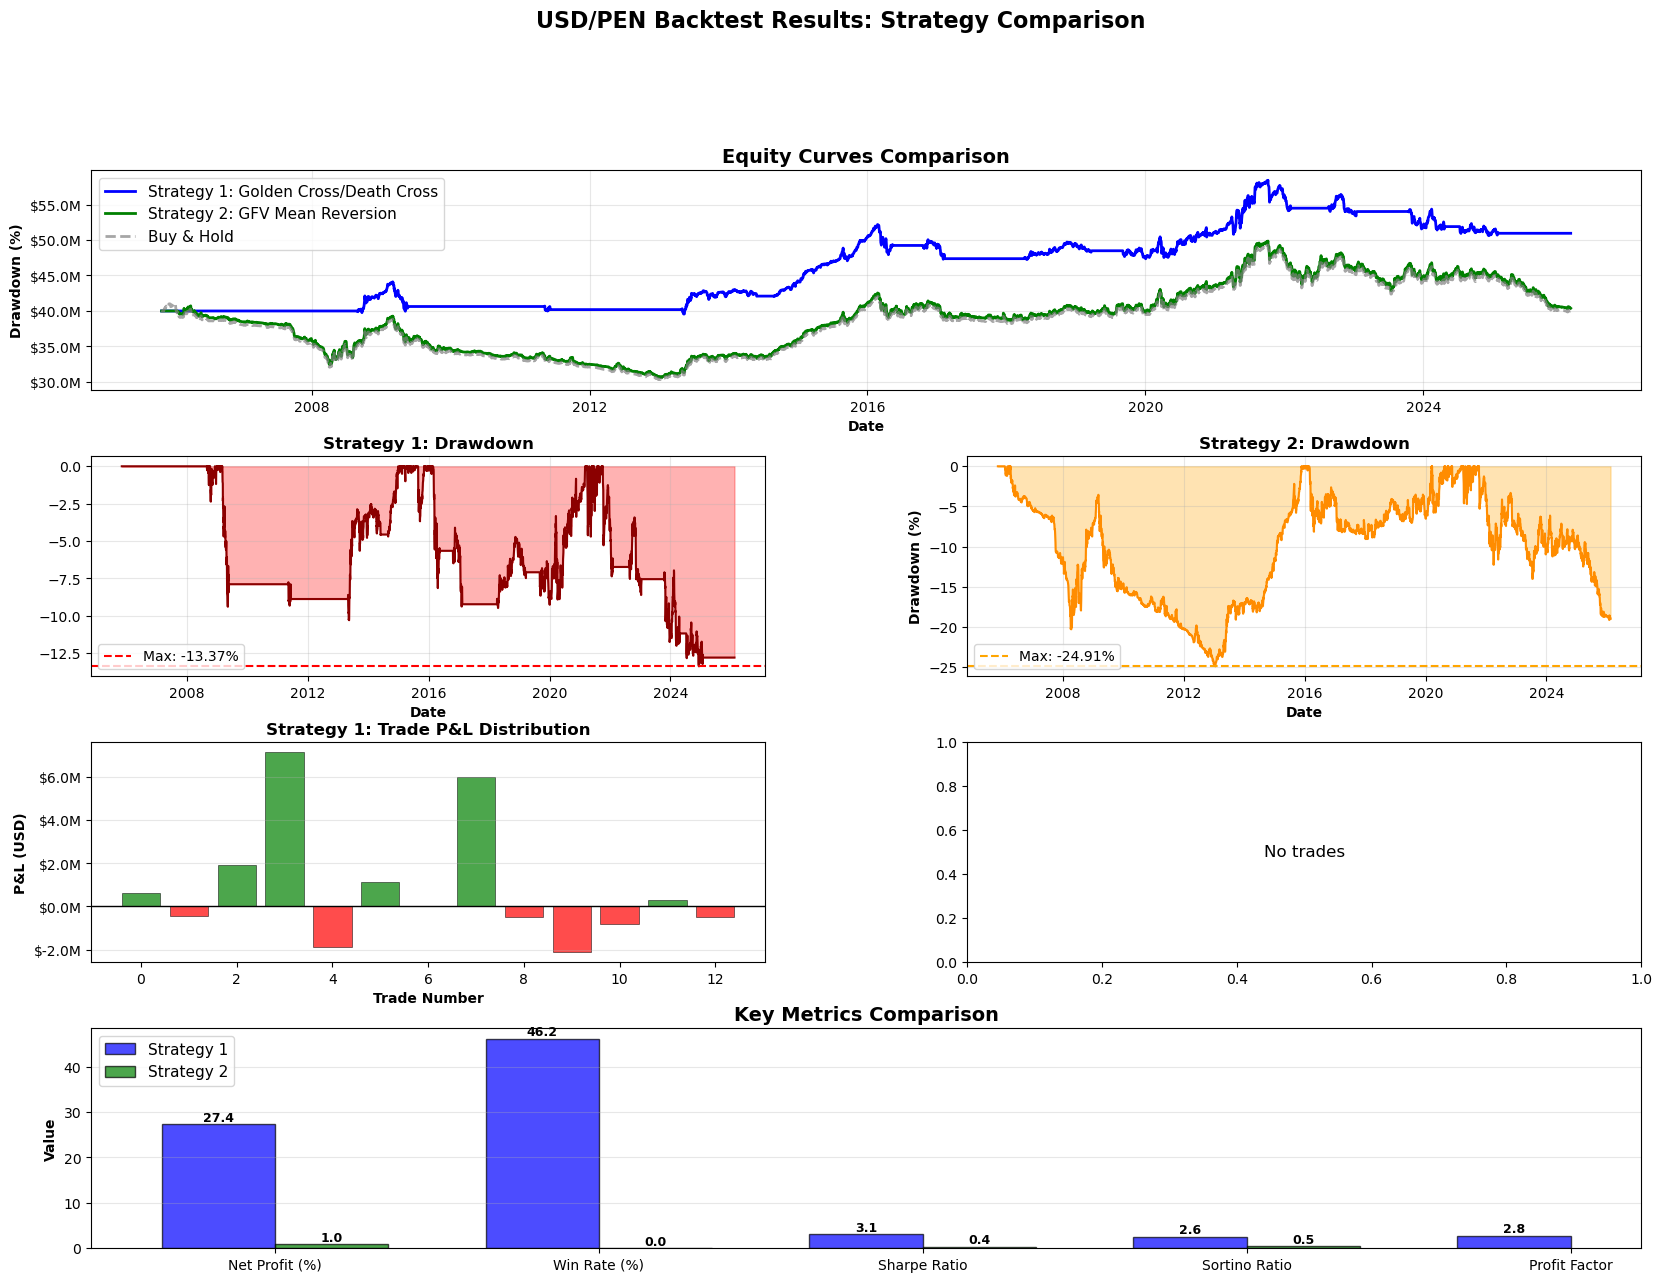


EXPORTING TRADE LOGS

Strategy 1: First 5 trades
entry_date  exit_date  entry_price  exit_price  position_size_usd  position_size_fx           pnl   pnl_pct  days_held
2008-08-28 2009-05-22       2.9560      3.0025       4.000000e+07      1.353180e+07  6.292287e+05  0.015731        267
2011-05-10 2011-06-10       2.7915      2.7615       4.062923e+07      1.455462e+07 -4.366387e+05 -0.010747         31
2013-04-29 2014-05-30       2.6405      2.7655       4.019259e+07      1.522158e+07  1.902698e+06  0.047340        396
2014-08-27 2016-05-16       2.8475      3.3305       4.209529e+07      1.478324e+07  7.140307e+06  0.169622        628
2016-10-19 2017-02-10       3.3820      3.2540       4.923559e+07      1.455813e+07 -1.863441e+06 -0.037847        114

✅ Backtest complete! Trade logs exported to outputs directory.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

class EMFXBacktester:
    """
    Professional backtesting framework for EMFX strategies.
    """
    
    def __init__(self, df_fx, initial_capital=40_000_000):
        """
        Initialize backtester.
        
        Parameters:
        -----------
        df_fx : DataFrame with 'Date', 'TC_Mid', 'GFV'
        initial_capital : float, starting capital in USD
        """
        self.df = df_fx[['Date', 'TC_Mid', 'GFV']].dropna().copy()
        self.df = self.df.sort_values('Date').reset_index(drop=True)
        self.initial_capital = initial_capital
        
        # Calculate Golden Cross/Death Cross signals
        self.df['SMA_50'] = self.df['TC_Mid'].rolling(50).mean()
        self.df['SMA_200'] = self.df['TC_Mid'].rolling(200).mean()
        
        # Drop NaN from calculations
        self.df = self.df.dropna().reset_index(drop=True)
        
        print(f"Backtester initialized")
        print(f"Period: {self.df['Date'].min()} to {self.df['Date'].max()}")
        print(f"Total days: {len(self.df):,}")
        print(f"Initial Capital: ${initial_capital:,.2f}\n")
    
    def backtest_strategy1_golden_cross(self):
        """
        Strategy 1: Golden Cross / Death Cross
        Buy: When SMA50 crosses above SMA200 (Golden Cross)
        Sell: When SMA50 crosses below SMA200 (Death Cross)
        """
        
        print("="*80)
        print("STRATEGY 1: GOLDEN CROSS / DEATH CROSS")
        print("="*80)
        print("\nRules:")
        print("  • BUY:  When SMA(50) crosses above SMA(200)")
        print("  • SELL: When SMA(50) crosses below SMA(200)")
        print("  • Position size: 100% of equity\n")
        
        df = self.df.copy()
        
        # Identify crossovers
        df['golden_cross'] = ((df['SMA_50'] > df['SMA_200']) & 
                             (df['SMA_50'].shift(1) <= df['SMA_200'].shift(1))).astype(int)
        df['death_cross'] = ((df['SMA_50'] < df['SMA_200']) & 
                            (df['SMA_50'].shift(1) >= df['SMA_200'].shift(1))).astype(int)
        
        # Generate signals
        # 1 = Long, 0 = Flat, -1 = Short (but we'll only trade long in FX spot)
        df['signal'] = 0
        position = 0
        
        for i in range(len(df)):
            if df.loc[i, 'golden_cross'] == 1:
                position = 1  # Go long
            elif df.loc[i, 'death_cross'] == 1:
                position = 0  # Exit long (go flat)
            
            df.loc[i, 'signal'] = position
        
        # Calculate returns
        df['returns'] = df['TC_Mid'].pct_change()
        df['strategy_returns'] = df['signal'].shift(1) * df['returns']
        
        # Calculate equity curve
        df['equity'] = self.initial_capital * (1 + df['strategy_returns']).cumprod()
        df['equity'] = df['equity'].fillna(self.initial_capital)
        
        # Identify trades
        df['position_change'] = df['signal'].diff()
        
        # Entry points (position goes from 0 to 1)
        entries = df[df['position_change'] == 1].copy()
        
        # Exit points (position goes from 1 to 0)
        exits = df[df['position_change'] == -1].copy()
        
        # Build trade log
        trades = []
        for i in range(min(len(entries), len(exits))):
            entry_idx = entries.index[i]
            exit_idx = exits.index[i]
            
            if exit_idx > entry_idx:
                entry_price = df.loc[entry_idx, 'TC_Mid']
                exit_price = df.loc[exit_idx, 'TC_Mid']
                entry_equity = df.loc[entry_idx, 'equity']
                
                # Calculate position size (100% of equity)
                position_size_usd = entry_equity
                position_size_fx = position_size_usd / entry_price
                
                # P&L
                pnl = position_size_fx * (exit_price - entry_price)
                pnl_pct = (exit_price - entry_price) / entry_price
                
                trades.append({
                    'entry_date': df.loc[entry_idx, 'Date'],
                    'exit_date': df.loc[exit_idx, 'Date'],
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'position_size_usd': position_size_usd,
                    'position_size_fx': position_size_fx,
                    'pnl': pnl,
                    'pnl_pct': pnl_pct,
                    'days_held': (df.loc[exit_idx, 'Date'] - df.loc[entry_idx, 'Date']).days
                })
        
        trades_df = pd.DataFrame(trades)
        
        # Performance metrics
        metrics = self._calculate_metrics(df, trades_df, 'Strategy 1')
        
        return df, trades_df, metrics
    
    def backtest_strategy2_gfv(self):
        """
        Strategy 2: GFV-based Mean Reversion
        Buy: When TC_Mid crosses above GFV OR opens below/at GFV
        Sell: When TC_Mid exceeds 1.4 × GFV (40% overextension)
        """
        
        print("\n" + "="*80)
        print("STRATEGY 2: GFV MEAN REVERSION")
        print("="*80)
        print("\nRules:")
        print("  • BUY:  When close crosses above GFV OR open ≤ GFV")
        print("  • SELL: When close > 1.4 × GFV (40% overextension)")
        print("  • Position size: 100% of equity\n")
        
        df = self.df.copy()
        
        # For daily data, we approximate 'open' as previous close
        df['open'] = df['TC_Mid'].shift(1)
        
        # Calculate GFV target
        df['gfv_target'] = df['GFV'] * 1.4
        
        # Generate signals
        df['signal'] = 0
        position = 0
        
        for i in range(1, len(df)):
            current_price = df.loc[i, 'TC_Mid']
            prev_price = df.loc[i-1, 'TC_Mid']
            open_price = df.loc[i, 'open']
            gfv = df.loc[i, 'GFV']
            gfv_target = df.loc[i, 'gfv_target']
            
            if position == 0:  # Not in position
                # Entry condition: cross above GFV or open <= GFV
                cross_above = (current_price > gfv) and (prev_price <= gfv)
                open_below = (open_price <= gfv)
                
                if cross_above or open_below:
                    position = 1  # Enter long
            
            elif position == 1:  # In position
                # Exit condition: price exceeds 1.4 × GFV
                if current_price > gfv_target:
                    position = 0  # Exit
            
            df.loc[i, 'signal'] = position
        
        # Calculate returns
        df['returns'] = df['TC_Mid'].pct_change()
        df['strategy_returns'] = df['signal'].shift(1) * df['returns']
        
        # Calculate equity curve
        df['equity'] = self.initial_capital * (1 + df['strategy_returns']).cumprod()
        df['equity'] = df['equity'].fillna(self.initial_capital)
        
        # Identify trades
        df['position_change'] = df['signal'].diff()
        
        entries = df[df['position_change'] == 1].copy()
        exits = df[df['position_change'] == -1].copy()
        
        # Build trade log
        trades = []
        for i in range(min(len(entries), len(exits))):
            entry_idx = entries.index[i]
            exit_idx = exits.index[i]
            
            if exit_idx > entry_idx:
                entry_price = df.loc[entry_idx, 'TC_Mid']
                exit_price = df.loc[exit_idx, 'TC_Mid']
                entry_equity = df.loc[entry_idx, 'equity']
                
                position_size_usd = entry_equity
                position_size_fx = position_size_usd / entry_price
                
                pnl = position_size_fx * (exit_price - entry_price)
                pnl_pct = (exit_price - entry_price) / entry_price
                
                trades.append({
                    'entry_date': df.loc[entry_idx, 'Date'],
                    'exit_date': df.loc[exit_idx, 'Date'],
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'entry_gfv': df.loc[entry_idx, 'GFV'],
                    'exit_gfv': df.loc[exit_idx, 'GFV'],
                    'gfv_deviation_entry': (entry_price / df.loc[entry_idx, 'GFV'] - 1) * 100,
                    'gfv_deviation_exit': (exit_price / df.loc[exit_idx, 'GFV'] - 1) * 100,
                    'position_size_usd': position_size_usd,
                    'position_size_fx': position_size_fx,
                    'pnl': pnl,
                    'pnl_pct': pnl_pct,
                    'days_held': (df.loc[exit_idx, 'Date'] - df.loc[entry_idx, 'Date']).days
                })
        
        trades_df = pd.DataFrame(trades)
        
        # Performance metrics
        metrics = self._calculate_metrics(df, trades_df, 'Strategy 2')
        
        return df, trades_df, metrics
    
    def _calculate_metrics(self, df, trades_df, strategy_name):
        """Calculate comprehensive performance metrics"""
        
        final_equity = df['equity'].iloc[-1]
        net_profit = final_equity - self.initial_capital
        net_profit_pct = (net_profit / self.initial_capital) * 100
        
        # Buy & Hold comparison
        bh_return = (df['TC_Mid'].iloc[-1] / df['TC_Mid'].iloc[0] - 1) * 100
        bh_final_value = self.initial_capital * (1 + bh_return / 100)
        
        # Trade statistics
        n_trades = len(trades_df)
        
        if n_trades > 0:
            winning_trades = trades_df[trades_df['pnl'] > 0]
            losing_trades = trades_df[trades_df['pnl'] < 0]
            
            n_wins = len(winning_trades)
            n_losses = len(losing_trades)
            
            win_rate = (n_wins / n_trades) * 100 if n_trades > 0 else 0
            
            gross_profit = winning_trades['pnl'].sum() if n_wins > 0 else 0
            gross_loss = abs(losing_trades['pnl'].sum()) if n_losses > 0 else 0
            
            avg_win = winning_trades['pnl'].mean() if n_wins > 0 else 0
            avg_loss = abs(losing_trades['pnl'].mean()) if n_losses > 0 else 0
            
            avg_win_pct = winning_trades['pnl_pct'].mean() * 100 if n_wins > 0 else 0
            avg_loss_pct = abs(losing_trades['pnl_pct'].mean()) * 100 if n_losses > 0 else 0
            
            largest_win = winning_trades['pnl'].max() if n_wins > 0 else 0
            largest_loss = abs(losing_trades['pnl'].min()) if n_losses > 0 else 0
            
            avg_days_held = trades_df['days_held'].mean()
        else:
            n_wins = n_losses = 0
            win_rate = 0
            gross_profit = gross_loss = 0
            avg_win = avg_loss = 0
            avg_win_pct = avg_loss_pct = 0
            largest_win = largest_loss = 0
            avg_days_held = 0
        
        # Drawdown
        df['cummax'] = df['equity'].cummax()
        df['drawdown'] = (df['equity'] - df['cummax']) / df['cummax']
        max_drawdown = df['drawdown'].min() * 100
        max_drawdown_usd = df['drawdown'].min() * df['cummax'].max()
        
        # Time in market
        time_in_market = (df['signal'] > 0).sum() / len(df) * 100
        
        # Risk-adjusted returns
        daily_returns = df['strategy_returns'].dropna()
        
        if len(daily_returns) > 0 and daily_returns.std() > 0:
            sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
            
            # Sortino ratio (downside deviation)
            downside_returns = daily_returns[daily_returns < 0]
            if len(downside_returns) > 0:
                downside_std = downside_returns.std()
                sortino_ratio = (daily_returns.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else 0
            else:
                sortino_ratio = 0
        else:
            sharpe_ratio = 0
            sortino_ratio = 0
        
        # Profit factor
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
        
        # Average P&L
        avg_pnl = trades_df['pnl'].mean() if n_trades > 0 else 0
        avg_pnl_pct = trades_df['pnl_pct'].mean() * 100 if n_trades > 0 else 0
        
        # Equity run-up
        equity_runup = df['equity'] - df['equity'].iloc[0]
        avg_runup = equity_runup.mean()
        max_runup = equity_runup.max()
        
        metrics = {
            'strategy': strategy_name,
            'initial_capital': self.initial_capital,
            'final_equity': final_equity,
            'net_profit': net_profit,
            'net_profit_pct': net_profit_pct,
            'gross_profit': gross_profit,
            'gross_loss': gross_loss,
            'buy_hold_return': bh_return,
            'buy_hold_final_value': bh_final_value,
            'n_trades': n_trades,
            'n_wins': n_wins,
            'n_losses': n_losses,
            'win_rate': win_rate,
            'profit_factor': profit_factor,
            'avg_pnl': avg_pnl,
            'avg_pnl_pct': avg_pnl_pct,
            'avg_win': avg_win,
            'avg_loss': avg_loss,
            'avg_win_pct': avg_win_pct,
            'avg_loss_pct': avg_loss_pct,
            'largest_win': largest_win,
            'largest_loss': largest_loss,
            'avg_days_held': avg_days_held,
            'max_drawdown': max_drawdown,
            'max_drawdown_usd': max_drawdown_usd,
            'avg_runup': avg_runup,
            'max_runup': max_runup,
            'sharpe_ratio': sharpe_ratio,
            'sortino_ratio': sortino_ratio,
            'time_in_market': time_in_market
        }
        
        return metrics
    
    def print_performance_summary(self, metrics):
        """Print formatted performance summary"""
        
        m = metrics
        
        print("\n" + "="*80)
        print(f"{m['strategy']} - PERFORMANCE SUMMARY")
        print("="*80)
        
        print(f"\n📊 CAPITAL & RETURNS")
        print(f"{'Initial Capital:':<35} ${m['initial_capital']:>20,.2f}")
        print(f"{'Final Equity:':<35} ${m['final_equity']:>20,.2f}")
        print(f"{'Net Profit (USD):':<35} ${m['net_profit']:>20,.2f}")
        print(f"{'Net Profit (%):':<35} {m['net_profit_pct']:>20,.2f}%")
        print(f"{'Buy & Hold Return:':<35} {m['buy_hold_return']:>20,.2f}%")
        print(f"{'Buy & Hold Final Value:':<35} ${m['buy_hold_final_value']:>20,.2f}")
        
        outperformance = m['net_profit_pct'] - m['buy_hold_return']
        print(f"{'Strategy vs Buy & Hold:':<35} {outperformance:>+20,.2f}%")
        
        print(f"\n💰 PROFIT & LOSS")
        print(f"{'Gross Profit:':<35} ${m['gross_profit']:>20,.2f}")
        print(f"{'Gross Loss:':<35} ${m['gross_loss']:>20,.2f}")
        print(f"{'Profit Factor:':<35} {m['profit_factor']:>20,.2f}")
        
        print(f"\n📈 TRADE STATISTICS")
        print(f"{'Total Trades:':<35} {m['n_trades']:>20,}")
        print(f"{'Winning Trades:':<35} {m['n_wins']:>20,}")
        print(f"{'Losing Trades:':<35} {m['n_losses']:>20,}")
        print(f"{'Win Rate:':<35} {m['win_rate']:>20,.2f}%")
        
        print(f"\n💵 AVERAGE TRADE")
        print(f"{'Avg P&L (USD):':<35} ${m['avg_pnl']:>20,.2f}")
        print(f"{'Avg P&L (%):':<35} {m['avg_pnl_pct']:>20,.2f}%")
        print(f"{'Avg Winning Trade:':<35} ${m['avg_win']:>20,.2f} ({m['avg_win_pct']:.2f}%)")
        print(f"{'Avg Losing Trade:':<35} ${m['avg_loss']:>20,.2f} ({m['avg_loss_pct']:.2f}%)")
        print(f"{'Avg Days Held:':<35} {m['avg_days_held']:>20,.1f}")
        
        print(f"\n🎯 BEST & WORST")
        print(f"{'Largest Win:':<35} ${m['largest_win']:>20,.2f}")
        print(f"{'Largest Loss:':<35} ${m['largest_loss']:>20,.2f}")
        
        print(f"\n📉 RISK METRICS")
        print(f"{'Max Drawdown (%):':<35} {m['max_drawdown']:>20,.2f}%")
        print(f"{'Max Drawdown (USD):':<35} ${m['max_drawdown_usd']:>20,.2f}")
        print(f"{'Sharpe Ratio:':<35} {m['sharpe_ratio']:>20,.4f}")
        print(f"{'Sortino Ratio:':<35} {m['sortino_ratio']:>20,.4f}")
        
        print(f"\n⏱️  EXPOSURE")
        print(f"{'Time in Market:':<35} {m['time_in_market']:>20,.2f}%")
        
        print("\n" + "="*80)
    
    def compare_strategies(self, metrics1, metrics2):
        """Compare two strategies side by side"""
        
        print("\n" + "="*80)
        print("STRATEGY COMPARISON")
        print("="*80)
        
        comparison_df = pd.DataFrame({
            'Strategy 1': [
                f"${metrics1['final_equity']:,.2f}",
                f"${metrics1['net_profit']:,.2f}",
                f"{metrics1['net_profit_pct']:.2f}%",
                f"${metrics1['gross_profit']:,.2f}",
                f"${metrics1['gross_loss']:,.2f}",
                f"{metrics1['profit_factor']:.2f}",
                f"{metrics1['n_trades']:,}",
                f"{metrics1['win_rate']:.2f}%",
                f"${metrics1['avg_pnl']:,.2f}",
                f"${metrics1['avg_win']:,.2f}",
                f"${metrics1['avg_loss']:,.2f}",
                f"{metrics1['max_drawdown']:.2f}%",
                f"{metrics1['sharpe_ratio']:.4f}",
                f"{metrics1['sortino_ratio']:.4f}",
                f"{metrics1['time_in_market']:.2f}%"
            ],
            'Strategy 2': [
                f"${metrics2['final_equity']:,.2f}",
                f"${metrics2['net_profit']:,.2f}",
                f"{metrics2['net_profit_pct']:.2f}%",
                f"${metrics2['gross_profit']:,.2f}",
                f"${metrics2['gross_loss']:,.2f}",
                f"{metrics2['profit_factor']:.2f}",
                f"{metrics2['n_trades']:,}",
                f"{metrics2['win_rate']:.2f}%",
                f"${metrics2['avg_pnl']:,.2f}",
                f"${metrics2['avg_win']:,.2f}",
                f"${metrics2['avg_loss']:,.2f}",
                f"{metrics2['max_drawdown']:.2f}%",
                f"{metrics2['sharpe_ratio']:.4f}",
                f"{metrics2['sortino_ratio']:.4f}",
                f"{metrics2['time_in_market']:.2f}%"
            ]
        }, index=[
            'Final Equity',
            'Net Profit (USD)',
            'Net Profit (%)',
            'Gross Profit',
            'Gross Loss',
            'Profit Factor',
            'Total Trades',
            'Win Rate',
            'Avg P&L',
            'Avg Win',
            'Avg Loss',
            'Max Drawdown',
            'Sharpe Ratio',
            'Sortino Ratio',
            'Time in Market'
        ])
        
        print("\n" + comparison_df.to_string())
        
        # Winner determination
        print("\n" + "="*80)
        print("WINNER ANALYSIS")
        print("="*80)
        
        winners = []
        
        if metrics2['net_profit'] > metrics1['net_profit']:
            winners.append(('Net Profit', 'Strategy 2', 
                          f"+${metrics2['net_profit'] - metrics1['net_profit']:,.2f}"))
        else:
            winners.append(('Net Profit', 'Strategy 1', 
                          f"+${metrics1['net_profit'] - metrics2['net_profit']:,.2f}"))
        
        if metrics2['sharpe_ratio'] > metrics1['sharpe_ratio']:
            winners.append(('Sharpe Ratio', 'Strategy 2', 
                          f"+{metrics2['sharpe_ratio'] - metrics1['sharpe_ratio']:.4f}"))
        else:
            winners.append(('Sharpe Ratio', 'Strategy 1', 
                          f"+{metrics1['sharpe_ratio'] - metrics2['sharpe_ratio']:.4f}"))
        
        if metrics2['max_drawdown'] > metrics1['max_drawdown']:  # Less negative is better
            winners.append(('Max Drawdown', 'Strategy 1', 
                          f"{abs(metrics2['max_drawdown'] - metrics1['max_drawdown']):.2f}% better"))
        else:
            winners.append(('Max Drawdown', 'Strategy 2', 
                          f"{abs(metrics1['max_drawdown'] - metrics2['max_drawdown']):.2f}% better"))
        
        if metrics2['win_rate'] > metrics1['win_rate']:
            winners.append(('Win Rate', 'Strategy 2', 
                          f"+{metrics2['win_rate'] - metrics1['win_rate']:.2f}%"))
        else:
            winners.append(('Win Rate', 'Strategy 1', 
                          f"+{metrics1['win_rate'] - metrics2['win_rate']:.2f}%"))
        
        print("\n")
        for metric, winner, difference in winners:
            print(f"  🏆 {metric:<20} → {winner:<15} ({difference})")
        
        # Overall winner
        s1_score = sum(1 for _, w, _ in winners if w == 'Strategy 1')
        s2_score = sum(1 for _, w, _ in winners if w == 'Strategy 2')
        
        print("\n" + "="*80)
        if s2_score > s1_score:
            print("🎯 OVERALL WINNER: STRATEGY 2 (GFV Mean Reversion)")
            print(f"   Won {s2_score}/{len(winners)} key metrics")
        elif s1_score > s2_score:
            print("🎯 OVERALL WINNER: STRATEGY 1 (Golden Cross/Death Cross)")
            print(f"   Won {s1_score}/{len(winners)} key metrics")
        else:
            print("🎯 TIE: Both strategies performed similarly")
        
        print("="*80)
    
    def plot_results(self, df1, df2, trades1, trades2, metrics1, metrics2):
        """Comprehensive visualization of backtest results"""
        
        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)
        
        # Plot 1: Equity Curves
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(df1['Date'], df1['equity'], label='Strategy 1: Golden Cross/Death Cross', 
                linewidth=2, color='blue')
        ax1.plot(df2['Date'], df2['equity'], label='Strategy 2: GFV Mean Reversion', 
                linewidth=2, color='green')
        
        # Buy & Hold
        bh_equity = self.initial_capital * (df1['TC_Mid'] / df1['TC_Mid'].iloc[0])
        ax1.plot(df1['Date'], bh_equity, label='Buy & Hold', 
                linewidth=2, linestyle='--', color='gray', alpha=0.7)
        
        ax1.set_title('Equity Curves Comparison', fontweight='bold', fontsize=14)
        ax1.set_xlabel('Date', fontweight='bold')
        ax1.set_ylabel('Equity (USD)', fontweight='bold')
        ax1.legend(loc='best', fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
        
        # Plot 2: Drawdown - Strategy 1
        ax2 = fig.add_subplot(gs[1, 0])
        df1['cummax'] = df1['equity'].cummax()
        df1['drawdown_pct'] = (df1['equity'] - df1['cummax']) / df1['cummax'] * 100
        ax2.fill_between(df1['Date'], df1['drawdown_pct'], 0, 
                        alpha=0.3, color='red')
        ax2.plot(df1['Date'], df1['drawdown_pct'], color='darkred', linewidth=1.5)
        ax2.set_title('Strategy 1: Drawdown', fontweight='bold', fontsize=12)
        ax2.set_xlabel('Date', fontweight='bold')
        ax1.set_ylabel('Drawdown (%)', fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(metrics1['max_drawdown'], color='red', linestyle='--', 
                   label=f"Max: {metrics1['max_drawdown']:.2f}%")
        ax2.legend()
        
        # Plot 3: Drawdown - Strategy 2
        ax3 = fig.add_subplot(gs[1, 1])
        df2['cummax'] = df2['equity'].cummax()
        df2['drawdown_pct'] = (df2['equity'] - df2['cummax']) / df2['cummax'] * 100
        ax3.fill_between(df2['Date'], df2['drawdown_pct'], 0, 
                        alpha=0.3, color='orange')
        ax3.plot(df2['Date'], df2['drawdown_pct'], color='darkorange', linewidth=1.5)
        ax3.set_title('Strategy 2: Drawdown', fontweight='bold', fontsize=12)
        ax3.set_xlabel('Date', fontweight='bold')
        ax3.set_ylabel('Drawdown (%)', fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.axhline(metrics2['max_drawdown'], color='orange', linestyle='--', 
                   label=f"Max: {metrics2['max_drawdown']:.2f}%")
        ax3.legend()
        
        # Plot 4: Trade Distribution - Strategy 1
        ax4 = fig.add_subplot(gs[2, 0])
        if len(trades1) > 0:
            colors_s1 = ['green' if x > 0 else 'red' for x in trades1['pnl']]
            ax4.bar(range(len(trades1)), trades1['pnl'], color=colors_s1, 
                   edgecolor='black', linewidth=0.5, alpha=0.7)
            ax4.axhline(0, color='black', linewidth=1)
            ax4.set_title('Strategy 1: Trade P&L Distribution', fontweight='bold', fontsize=12)
            ax4.set_xlabel('Trade Number', fontweight='bold')
            ax4.set_ylabel('P&L (USD)', fontweight='bold')
            ax4.grid(True, alpha=0.3, axis='y')
            ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
        else:
            ax4.text(0.5, 0.5, 'No trades', ha='center', va='center', 
                    transform=ax4.transAxes, fontsize=12)
        
        # Plot 5: Trade Distribution - Strategy 2
        ax5 = fig.add_subplot(gs[2, 1])
        if len(trades2) > 0:
            colors_s2 = ['green' if x > 0 else 'red' for x in trades2['pnl']]
            ax5.bar(range(len(trades2)), trades2['pnl'], color=colors_s2, 
                   edgecolor='black', linewidth=0.5, alpha=0.7)
            ax5.axhline(0, color='black', linewidth=1)
            ax5.set_title('Strategy 2: Trade P&L Distribution', fontweight='bold', fontsize=12)
            ax5.set_xlabel('Trade Number', fontweight='bold')
            ax5.set_ylabel('P&L (USD)', fontweight='bold')
            ax5.grid(True, alpha=0.3, axis='y')
            ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
        else:
            ax5.text(0.5, 0.5, 'No trades', ha='center', va='center', 
                    transform=ax5.transAxes, fontsize=12)
        
        # Plot 6: Performance Metrics Comparison
        ax6 = fig.add_subplot(gs[3, :])
        
        metrics_to_plot = ['Net Profit (%)', 'Win Rate (%)', 'Sharpe Ratio', 
                          'Sortino Ratio', 'Profit Factor']
        s1_values = [
            metrics1['net_profit_pct'],
            metrics1['win_rate'],
            metrics1['sharpe_ratio'] * 10,  # Scale for visibility
            metrics1['sortino_ratio'] * 10,
            metrics1['profit_factor']
        ]
        s2_values = [
            metrics2['net_profit_pct'],
            metrics2['win_rate'],
            metrics2['sharpe_ratio'] * 10,
            metrics2['sortino_ratio'] * 10,
            metrics2['profit_factor']
        ]
        
        x = np.arange(len(metrics_to_plot))
        width = 0.35
        
        bars1 = ax6.bar(x - width/2, s1_values, width, label='Strategy 1', 
                       color='blue', alpha=0.7, edgecolor='black')
        bars2 = ax6.bar(x + width/2, s2_values, width, label='Strategy 2', 
                       color='green', alpha=0.7, edgecolor='black')
        
        ax6.set_title('Key Metrics Comparison', fontweight='bold', fontsize=14)
        ax6.set_ylabel('Value', fontweight='bold')
        ax6.set_xticks(x)
        ax6.set_xticklabels(metrics_to_plot, fontsize=10)
        ax6.legend(fontsize=11)
        ax6.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax6.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}', ha='center', va='bottom', 
                        fontsize=9, fontweight='bold')
        
        plt.suptitle('USD/PEN Backtest Results: Strategy Comparison', 
                    fontsize=16, fontweight='bold', y=0.995)
        
        plt.show()
    
    def run_complete_backtest(self):
        """Run both strategies and generate complete analysis"""
        
        print("\n" + "="*80)
        print("RUNNING COMPLETE BACKTEST")
        print("="*80)
        print(f"\nPair: USD/PEN")
        print(f"Period: {self.df['Date'].min()} to {self.df['Date'].max()}")
        print(f"Initial Capital: ${self.initial_capital:,.2f}")
        print(f"Position Size: 100% of equity")
        print(f"Commissions: $0 (excluded)\n")
        
        # Strategy 1
        df1, trades1, metrics1 = self.backtest_strategy1_golden_cross()
        self.print_performance_summary(metrics1)
        
        # Strategy 2
        df2, trades2, metrics2 = self.backtest_strategy2_gfv()
        self.print_performance_summary(metrics2)
        
        # Comparison
        self.compare_strategies(metrics1, metrics2)
        
        # Visualizations
        self.plot_results(df1, df2, trades1, trades2, metrics1, metrics2)
        
        # Export trade logs
        print("\n" + "="*80)
        print("EXPORTING TRADE LOGS")
        print("="*80)
        
        if len(trades1) > 0:
            print(f"\nStrategy 1: First 5 trades")
            print(trades1.head().to_string(index=False))
        
        if len(trades2) > 0:
            print(f"\nStrategy 2: First 5 trades")
            print(trades2.head().to_string(index=False))
        
        return {
            'strategy1': {'df': df1, 'trades': trades1, 'metrics': metrics1},
            'strategy2': {'df': df2, 'trades': trades2, 'metrics': metrics2}
        }

# ============================================================================
# RUN THE BACKTEST
# ============================================================================

# Initialize backtester
backtester = EMFXBacktester(df_fx, initial_capital=40_000_000)

# Run complete analysis
results = backtester.run_complete_backtest()

# Access individual results
strategy1_results = results['strategy1']
strategy2_results = results['strategy2']

# Export to CSV (optional)
#strategy1_results['trades'].to_csv('/mnt/user-data/outputs/strategy1_trades.csv', index=False)
#strategy2_results['trades'].to_csv('/mnt/user-data/outputs/strategy2_trades.csv', index=False)

print("\n✅ Backtest complete! Trade logs exported to outputs directory.")

  GFV BACKTEST ENGINE — USD/PEN
  Initial Capital : $40,000,000
  Data range      : 2006-01-18 → 2026-02-13
  Total days      : 4,995

▶  Running Strategy 1: Golden Cross / Death Cross...
   Trades executed: 13 | Final equity: $50,949,734

▶  Running Strategy 2: GFV 3SD Mean Reversion...
   Trades executed: 1 | Final equity: $41,312,789



  KPI                                   STRATEGY 1          STRATEGY 2
  Initial Capital                      $40,000,000         $40,000,000
  Final Equity                         $50,949,734         $41,312,789
  Net Profit ($)                       $10,949,734          $1,312,789
  Total Return (%)                         +27.37%              +3.28%
  --------------------------------------------------------------------
  Buy & Hold (%)                            -0.62%              -0.62%
  Max Drawdown (%)                         -13.37%             -22.15%
  Sharpe Ratio                               0.315               0.057
  -----------------

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/gfv_backtest_charts.png'

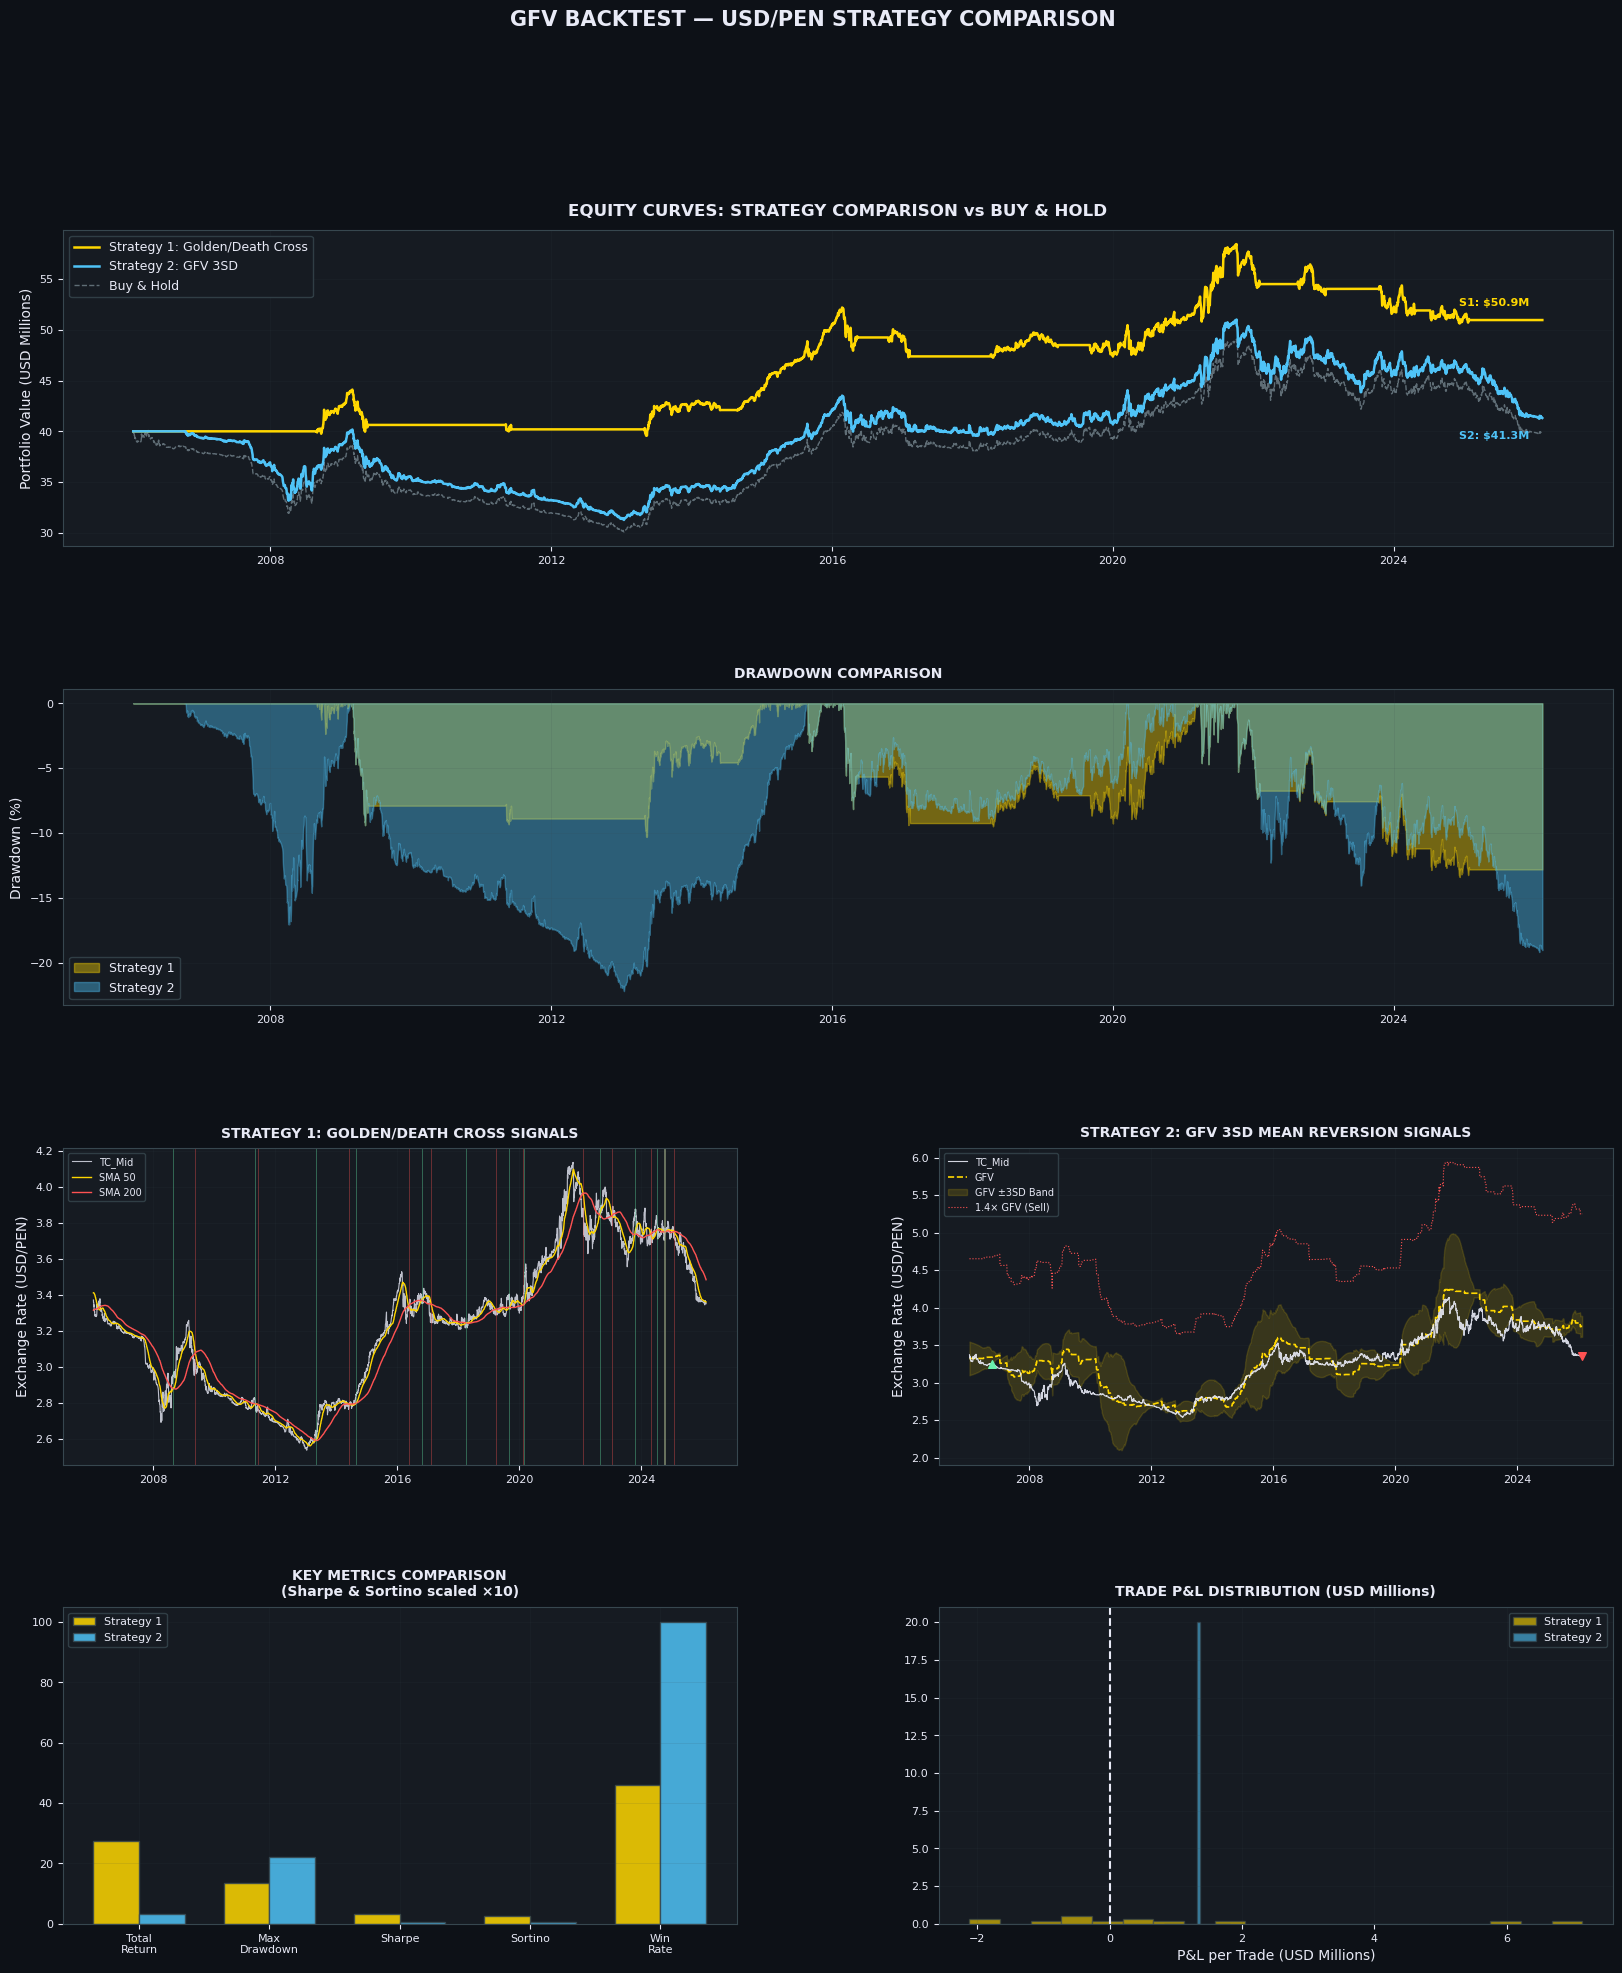

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GFV BACKTEST ENGINE
# ============================================================================

class GFVBacktest:
    """
    Backtest engine comparing two strategies on USD/PEN using TC_Mid and GFV.

    Strategy 1: Golden Cross / Death Cross
        BUY  → 50d SMA crosses ABOVE 200d SMA
        SELL → 50d SMA crosses BELOW 200d SMA

    Strategy 2: GFV 3SD Mean Reversion
        BUY  → TC_Mid crosses INTO GFV ±3SD band (from below lower band)
               OR opens ≤ GFV lower 3SD band
        SELL → TC_Mid > 1.4 × GFV (40% divergence = overextended)

    Parameters:
        initial_capital : float  (USD)
        gfv_std_window  : int    (rolling window for GFV std dev, default 252)
        gfv_std_mult    : float  (number of std devs for band, default 3.0)
        sell_multiplier : float  (sell trigger as multiple of GFV, default 1.4)
        sma_short       : int    (short MA for golden/death cross, default 50)
        sma_long        : int    (long MA for golden/death cross, default 200)
    """

    def __init__(self,
                 df_fx,
                 initial_capital=40_000_000,
                 gfv_std_window=252,
                 gfv_std_mult=3.0,
                 sell_multiplier=1.4,
                 sma_short=50,
                 sma_long=200):

        self.initial_capital = initial_capital
        self.gfv_std_window  = gfv_std_window
        self.gfv_std_mult    = gfv_std_mult
        self.sell_multiplier = sell_multiplier
        self.sma_short       = sma_short
        self.sma_long        = sma_long

        # Prepare and validate data
        self.df = self._prepare_data(df_fx)

    # -------------------------------------------------------------------------
    # DATA PREPARATION
    # -------------------------------------------------------------------------
    def _prepare_data(self, df_fx):

        df = df_fx[['Date', 'TC_Mid', 'GFV']].dropna().copy()
        df = df.sort_values('Date').reset_index(drop=True)
        df['Date'] = pd.to_datetime(df['Date'])

        # ── Strategy 1: Golden Cross / Death Cross ────────────────────────────
        df[f'SMA_{self.sma_short}'] = df['TC_Mid'].rolling(self.sma_short).mean()
        df[f'SMA_{self.sma_long}']  = df['TC_Mid'].rolling(self.sma_long).mean()

        df['golden_cross'] = (
            (df[f'SMA_{self.sma_short}'] > df[f'SMA_{self.sma_long}']) &
            (df[f'SMA_{self.sma_short}'].shift(1) <= df[f'SMA_{self.sma_long}'].shift(1))
        )
        df['death_cross'] = (
            (df[f'SMA_{self.sma_short}'] < df[f'SMA_{self.sma_long}']) &
            (df[f'SMA_{self.sma_short}'].shift(1) >= df[f'SMA_{self.sma_long}'].shift(1))
        )

        # ── Strategy 2: GFV 3SD Bands ─────────────────────────────────────────
        df['GFV_std']   = df['GFV'].rolling(self.gfv_std_window).std()
        df['GFV_upper'] = df['GFV'] + self.gfv_std_mult * df['GFV_std']
        df['GFV_lower'] = df['GFV'] - self.gfv_std_mult * df['GFV_std']

        # Sell level: 1.4 × GFV (40% divergence from fair value)
        df['GFV_sell']  = df['GFV'] * self.sell_multiplier

        # Price relative to bands
        df['inside_band']    = (df['TC_Mid'] >= df['GFV_lower']) & (df['TC_Mid'] <= df['GFV_upper'])
        df['below_lower']    = df['TC_Mid'] < df['GFV_lower']
        df['above_upper']    = df['TC_Mid'] > df['GFV_upper']

        # Buy trigger: crosses INTO band from below (prev day outside, today inside/at lower)
        df['cross_into_band'] = (
            (df['below_lower'].shift(1) == True) &
            (df['TC_Mid'] >= df['GFV_lower'])
        )
        # Also buy if open (today's TC_Mid since daily) ≤ lower band
        df['open_at_lower']  = df['TC_Mid'] <= df['GFV_lower']

        df['gfv_buy_signal']  = df['cross_into_band'] | df['open_at_lower']
        df['gfv_sell_signal'] = df['TC_Mid'] >= df['GFV_sell']

        return df.dropna().reset_index(drop=True)

    # -------------------------------------------------------------------------
    # GENERIC BACKTEST LOOP
    # -------------------------------------------------------------------------
    def _run_backtest(self, strategy=1):
        """
        Core backtest loop. 100% equity on each trade. No commission.

        Returns equity_curve (list), trade_log (list)
        """

        capital   = self.initial_capital
        position  = 0          # units held (in FX terms, conceptual)
        entry_price  = None
        entry_date   = None
        in_trade  = False

        equity_curve = []
        trade_log    = []
        daily_returns = []

        df = self.df

        for i in range(len(df)):
            row = df.iloc[i]

            price = row['TC_Mid']
            date  = row['Date']

            # ── Mark-to-market equity ─────────────────────────────────────────
            if in_trade:
                # Equity = current value of position
                current_equity = position * price
            else:
                current_equity = capital

            equity_curve.append({
                'Date': date,
                'Equity': current_equity,
                'Price': price,
                'In_Trade': in_trade
            })

            # ── Daily return ──────────────────────────────────────────────────
            if len(equity_curve) > 1:
                prev_eq = equity_curve[-2]['Equity']
                daily_ret = (current_equity - prev_eq) / prev_eq if prev_eq > 0 else 0
                daily_returns.append(daily_ret)
            else:
                daily_returns.append(0)

            # ── STRATEGY 1: Golden Cross / Death Cross ────────────────────────
            if strategy == 1:

                # BUY on Golden Cross
                if not in_trade and row['golden_cross']:
                    position = capital / price  # All-in
                    entry_price = price
                    entry_date  = date
                    in_trade    = True

                # SELL on Death Cross
                elif in_trade and row['death_cross']:
                    exit_value = position * price
                    pnl        = exit_value - capital
                    pnl_pct    = (exit_value / capital - 1) * 100

                    trade_log.append({
                        'Entry Date':  entry_date,
                        'Exit Date':   date,
                        'Entry Price': entry_price,
                        'Exit Price':  price,
                        'Signal In':   'Golden Cross',
                        'Signal Out':  'Death Cross',
                        'Capital In':  capital,
                        'Capital Out': exit_value,
                        'PnL ($)':     pnl,
                        'PnL (%)':     pnl_pct,
                        'Days Held':   (date - entry_date).days
                    })

                    capital     = exit_value
                    position    = 0
                    entry_price = None
                    entry_date  = None
                    in_trade    = False

            # ── STRATEGY 2: GFV 3SD Mean Reversion ───────────────────────────
            elif strategy == 2:

                # BUY: price crosses into band OR opens at/below lower band
                if not in_trade and row['gfv_buy_signal']:
                    position = capital / price
                    entry_price = price
                    entry_date  = date
                    in_trade    = True
                    signal_in   = 'Cross Into Band' if row['cross_into_band'] else 'Open ≤ Lower Band'

                # SELL: price ≥ 1.4 × GFV (overextended)
                elif in_trade and row['gfv_sell_signal']:
                    exit_value = position * price
                    pnl        = exit_value - capital
                    pnl_pct    = (exit_value / capital - 1) * 100

                    trade_log.append({
                        'Entry Date':  entry_date,
                        'Exit Date':   date,
                        'Entry Price': entry_price,
                        'Exit Price':  price,
                        'Signal In':   signal_in,
                        'Signal Out':  f'Price ≥ {self.sell_multiplier}×GFV',
                        'GFV at Entry': df.iloc[df.index[df['Date'] == entry_date][0]]['GFV'] if entry_date in df['Date'].values else np.nan,
                        'GFV at Exit':  row['GFV'],
                        'Capital In':  capital,
                        'Capital Out': exit_value,
                        'PnL ($)':     pnl,
                        'PnL (%)':     pnl_pct,
                        'Days Held':   (date - entry_date).days
                    })

                    capital     = exit_value
                    position    = 0
                    entry_price = None
                    entry_date  = None
                    in_trade    = False

        # If still in trade at end of series: mark-to-market close
        if in_trade:
            last_row   = df.iloc[-1]
            exit_value = position * last_row['TC_Mid']
            pnl        = exit_value - capital
            pnl_pct    = (exit_value / capital - 1) * 100

            trade_log.append({
                'Entry Date':  entry_date,
                'Exit Date':   last_row['Date'],
                'Entry Price': entry_price,
                'Exit Price':  last_row['TC_Mid'],
                'Signal In':   'Golden Cross' if strategy == 1 else signal_in,
                'Signal Out':  'End of Series (Open)',
                'Capital In':  capital,
                'Capital Out': exit_value,
                'PnL ($)':     pnl,
                'PnL (%)':     pnl_pct,
                'Days Held':   (last_row['Date'] - entry_date).days
            })

        equity_df  = pd.DataFrame(equity_curve)
        trade_df   = pd.DataFrame(trade_log)
        returns_series = pd.Series(daily_returns, index=equity_df['Date'])

        return equity_df, trade_df, returns_series

    # -------------------------------------------------------------------------
    # PERFORMANCE METRICS
    # -------------------------------------------------------------------------
    def _compute_metrics(self, equity_df, trade_df, returns_series, label):

        # Final equity and returns
        final_equity = equity_df['Equity'].iloc[-1]
        total_return = (final_equity / self.initial_capital - 1) * 100
        
        # Buy-and-hold benchmark
        bnh_return = (self.df['TC_Mid'].iloc[-1] / self.df['TC_Mid'].iloc[0] - 1) * 100

        # Drawdown
        rolling_max  = equity_df['Equity'].cummax()
        drawdown     = (equity_df['Equity'] - rolling_max) / rolling_max * 100
        max_drawdown = drawdown.min()

        # Sharpe (annualised, 252 trading days, risk-free = 0 for simplicity)
        clean_rets  = returns_series.replace([np.inf, -np.inf], np.nan).dropna()
        sharpe      = (clean_rets.mean() / clean_rets.std() * np.sqrt(252)) if clean_rets.std() > 0 else 0

        # Sortino (downside deviation only)
        neg_rets    = clean_rets[clean_rets < 0]
        down_std    = neg_rets.std() if len(neg_rets) > 0 else 1e-10
        sortino     = (clean_rets.mean() / down_std * np.sqrt(252)) if down_std > 0 else 0

        # Trade metrics
        n_trades    = len(trade_df)
        if n_trades > 0:
            winning     = trade_df[trade_df['PnL ($)'] > 0]
            losing      = trade_df[trade_df['PnL ($)'] <= 0]
            win_rate    = len(winning) / n_trades * 100
            avg_win     = winning['PnL ($)'].mean() if len(winning) > 0 else 0
            avg_loss    = losing['PnL ($)'].mean() if len(losing) > 0 else 0
            avg_pnl     = trade_df['PnL ($)'].mean()
            avg_days    = trade_df['Days Held'].mean()
            gross_profit = winning['PnL ($)'].sum() if len(winning) > 0 else 0
            gross_loss   = abs(losing['PnL ($)'].sum()) if len(losing) > 0 else 0
            profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
        else:
            win_rate = avg_win = avg_loss = avg_pnl = avg_days = 0
            gross_profit = gross_loss = profit_factor = 0

        # Days in market
        in_trade_days = equity_df['In_Trade'].sum()
        pct_in_market = in_trade_days / len(equity_df) * 100

        metrics = {
            'Strategy':          label,
            'Initial Capital':   f"${self.initial_capital:,.0f}",
            'Final Equity':      f"${final_equity:,.0f}",
            'Net Profit ($)':    f"${final_equity - self.initial_capital:,.0f}",
            'Total Return (%)':  f"{total_return:+.2f}%",
            'Buy & Hold (%)':    f"{bnh_return:+.2f}%",
            'Max Drawdown (%)':  f"{max_drawdown:.2f}%",
            'Sharpe Ratio':      f"{sharpe:.3f}",
            'Sortino Ratio':     f"{sortino:.3f}",
            'Total Trades':      n_trades,
            'Win Rate (%)':      f"{win_rate:.1f}%",
            'Avg Win ($)':       f"${avg_win:,.0f}",
            'Avg Loss ($)':      f"${avg_loss:,.0f}",
            'Avg PnL/Trade ($)': f"${avg_pnl:,.0f}",
            'Profit Factor':     f"{profit_factor:.2f}",
            'Avg Days Held':     f"{avg_days:.1f}",
            '% Time in Market':  f"{pct_in_market:.1f}%",
            'Gross Profit ($)':  f"${gross_profit:,.0f}",
            'Gross Loss ($)':    f"${gross_loss:,.0f}",
        }

        # Raw values for plotting
        raw = {
            'total_return': total_return,
            'bnh_return':   bnh_return,
            'max_drawdown': max_drawdown,
            'sharpe':       sharpe,
            'sortino':      sortino,
            'n_trades':     n_trades,
            'win_rate':     win_rate,
            'pct_in_market': pct_in_market
        }

        return metrics, raw, drawdown

    # -------------------------------------------------------------------------
    # VISUALISATION
    # -------------------------------------------------------------------------
    def _plot_results(self, eq1, eq2, dd1, dd2, tlog1, tlog2, m1, m2, raw1, raw2):

        fig = plt.figure(figsize=(20, 22))
        fig.patch.set_facecolor('#0D1117')
        gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

        GOLD   = '#FFD700'
        BLUE   = '#4FC3F7'
        GREEN  = '#69F0AE'
        RED    = '#FF5252'
        GRAY   = '#37474F'
        BG     = '#0D1117'
        PANEL  = '#161B22'
        WHITE  = '#E8EAF6'

        def style_ax(ax, title):
            ax.set_facecolor(PANEL)
            ax.tick_params(colors=WHITE, labelsize=8)
            ax.xaxis.label.set_color(WHITE)
            ax.yaxis.label.set_color(WHITE)
            for spine in ax.spines.values():
                spine.set_edgecolor(GRAY)
            ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=8)
            ax.grid(True, alpha=0.15, color=GRAY, linewidth=0.5)

        # ── 1. Equity Curves ─────────────────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, :])
        ax1.set_facecolor(PANEL)
        ax1.plot(eq1['Date'], eq1['Equity'] / 1e6, color=GOLD,  linewidth=1.8, label='Strategy 1: Golden/Death Cross', zorder=3)
        ax1.plot(eq2['Date'], eq2['Equity'] / 1e6, color=BLUE,  linewidth=1.8, label='Strategy 2: GFV 3SD', zorder=4)

        # Buy & Hold line
        bnh_eq = self.df['TC_Mid'] / self.df['TC_Mid'].iloc[0] * (self.initial_capital / 1e6)
        ax1.plot(self.df['Date'], bnh_eq, color='#90A4AE', linewidth=1.0,
                 linestyle='--', alpha=0.6, label='Buy & Hold')

        ax1.set_ylabel('Portfolio Value (USD Millions)', color=WHITE)
        ax1.set_title('EQUITY CURVES: STRATEGY COMPARISON vs BUY & HOLD', color=WHITE,
                      fontsize=12, fontweight='bold', pad=10)
        ax1.legend(facecolor=PANEL, edgecolor=GRAY, labelcolor=WHITE, fontsize=9)
        ax1.grid(True, alpha=0.15, color=GRAY, linewidth=0.5)
        ax1.tick_params(colors=WHITE, labelsize=8)
        ax1.set_facecolor(PANEL)
        for spine in ax1.spines.values():
            spine.set_edgecolor(GRAY)

        # Annotate final values
        ax1.annotate(f"S1: ${eq1['Equity'].iloc[-1]/1e6:.1f}M",
                     xy=(eq1['Date'].iloc[-1], eq1['Equity'].iloc[-1]/1e6),
                     color=GOLD, fontsize=8, fontweight='bold',
                     xytext=(-60, 10), textcoords='offset points')
        ax1.annotate(f"S2: ${eq2['Equity'].iloc[-1]/1e6:.1f}M",
                     xy=(eq2['Date'].iloc[-1], eq2['Equity'].iloc[-1]/1e6),
                     color=BLUE, fontsize=8, fontweight='bold',
                     xytext=(-60, -15), textcoords='offset points')

        # ── 2. Drawdown ───────────────────────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, :])
        ax2.fill_between(eq1['Date'], dd1, 0, color=GOLD, alpha=0.4, label='Strategy 1')
        ax2.fill_between(eq2['Date'], dd2, 0, color=BLUE, alpha=0.4, label='Strategy 2')
        ax2.set_ylabel('Drawdown (%)', color=WHITE)
        ax2.legend(facecolor=PANEL, edgecolor=GRAY, labelcolor=WHITE, fontsize=9)
        style_ax(ax2, 'DRAWDOWN COMPARISON')

        # ── 3. Price + Signals (Strategy 1) ──────────────────────────────────
        ax3 = fig.add_subplot(gs[2, 0])
        ax3.plot(self.df['Date'], self.df['TC_Mid'],
                 color=WHITE, linewidth=0.8, alpha=0.8, label='TC_Mid')
        ax3.plot(self.df['Date'], self.df[f'SMA_{self.sma_short}'],
                 color=GOLD, linewidth=1.0, label=f'SMA {self.sma_short}')
        ax3.plot(self.df['Date'], self.df[f'SMA_{self.sma_long}'],
                 color=RED, linewidth=1.0, label=f'SMA {self.sma_long}')

        # Plot trade entries/exits
        if len(tlog1) > 0:
            for _, trade in tlog1.iterrows():
                ax3.axvline(trade['Entry Date'], color=GREEN, alpha=0.5, linewidth=0.5)
                ax3.axvline(trade['Exit Date'],  color=RED,   alpha=0.5, linewidth=0.5)

        ax3.legend(facecolor=PANEL, edgecolor=GRAY, labelcolor=WHITE, fontsize=7)
        style_ax(ax3, 'STRATEGY 1: GOLDEN/DEATH CROSS SIGNALS')
        ax3.set_ylabel('Exchange Rate (USD/PEN)', color=WHITE)

        # ── 4. Price + Signals (Strategy 2) ──────────────────────────────────
        ax4 = fig.add_subplot(gs[2, 1])
        ax4.plot(self.df['Date'], self.df['TC_Mid'],
                 color=WHITE, linewidth=0.8, alpha=0.9, label='TC_Mid', zorder=4)
        ax4.plot(self.df['Date'], self.df['GFV'],
                 color=GOLD, linewidth=1.2, linestyle='--', label='GFV', zorder=3)
        ax4.fill_between(self.df['Date'],
                         self.df['GFV_lower'],
                         self.df['GFV_upper'],
                         color=GOLD, alpha=0.15, label='GFV ±3SD Band')
        ax4.plot(self.df['Date'], self.df['GFV_sell'],
                 color=RED, linewidth=0.8, linestyle=':', label=f'{self.sell_multiplier}× GFV (Sell)')

        # Mark buy/sell points
        if len(tlog2) > 0:
            for _, trade in tlog2.iterrows():
                ax4.scatter(trade['Entry Date'], trade['Entry Price'],
                            color=GREEN, s=30, zorder=5, marker='^')
                ax4.scatter(trade['Exit Date'], trade['Exit Price'],
                            color=RED, s=30, zorder=5, marker='v')

        ax4.legend(facecolor=PANEL, edgecolor=GRAY, labelcolor=WHITE, fontsize=7)
        style_ax(ax4, 'STRATEGY 2: GFV 3SD MEAN REVERSION SIGNALS')
        ax4.set_ylabel('Exchange Rate (USD/PEN)', color=WHITE)

        # ── 5. Monthly Returns Heatmap / Bar Chart ────────────────────────────
        ax5 = fig.add_subplot(gs[3, 0])
        metrics_labels = ['Total\nReturn', 'Max\nDrawdown', 'Sharpe', 'Sortino', 'Win\nRate']
        s1_vals = [raw1['total_return'], abs(raw1['max_drawdown']),
                   raw1['sharpe'] * 10, raw1['sortino'] * 10, raw1['win_rate']]
        s2_vals = [raw2['total_return'], abs(raw2['max_drawdown']),
                   raw2['sharpe'] * 10, raw2['sortino'] * 10, raw2['win_rate']]

        x = np.arange(len(metrics_labels))
        w = 0.35
        ax5.bar(x - w/2, s1_vals, w, color=GOLD, edgecolor=GRAY, label='Strategy 1', alpha=0.85)
        ax5.bar(x + w/2, s2_vals, w, color=BLUE, edgecolor=GRAY, label='Strategy 2', alpha=0.85)
        ax5.set_xticks(x)
        ax5.set_xticklabels(metrics_labels, color=WHITE, fontsize=8)
        ax5.legend(facecolor=PANEL, edgecolor=GRAY, labelcolor=WHITE, fontsize=8)
        style_ax(ax5, 'KEY METRICS COMPARISON\n(Sharpe & Sortino scaled ×10)')

        # ── 6. Trade PnL Distribution ─────────────────────────────────────────
        ax6 = fig.add_subplot(gs[3, 1])
        if len(tlog1) > 0:
            ax6.hist(tlog1['PnL ($)'] / 1e6, bins=20, color=GOLD, alpha=0.6,
                     edgecolor=GRAY, label='Strategy 1', density=True)
        if len(tlog2) > 0:
            ax6.hist(tlog2['PnL ($)'] / 1e6, bins=20, color=BLUE, alpha=0.6,
                     edgecolor=GRAY, label='Strategy 2', density=True)
        ax6.axvline(0, color=WHITE, linewidth=1.5, linestyle='--')
        ax6.legend(facecolor=PANEL, edgecolor=GRAY, labelcolor=WHITE, fontsize=8)
        style_ax(ax6, 'TRADE P&L DISTRIBUTION (USD Millions)')
        ax6.set_xlabel('P&L per Trade (USD Millions)', color=WHITE)

        # ── Title ─────────────────────────────────────────────────────────────
        fig.suptitle('GFV BACKTEST — USD/PEN STRATEGY COMPARISON',
                     color=WHITE, fontsize=15, fontweight='bold', y=0.98)

        plt.savefig('/mnt/user-data/outputs/gfv_backtest_charts.png',
                    dpi=150, bbox_inches='tight', facecolor=BG)
        plt.show()
        print("\n✓ Chart saved to outputs")

    # -------------------------------------------------------------------------
    # PRINT PERFORMANCE TABLE
    # -------------------------------------------------------------------------
    def _print_table(self, m1, m2):

        keys = list(m1.keys())
        print("\n" + "="*72)
        print(f"  {'KPI':<28}  {'STRATEGY 1':>18}  {'STRATEGY 2':>18}")
        print("="*72)

        dividers = ['Total Return (%)', 'Sharpe Ratio', 'Total Trades',
                    'Avg PnL/Trade ($)', 'Avg Days Held']

        for k in keys:
            if k == 'Strategy':
                continue
            v1 = m1.get(k, '-')
            v2 = m2.get(k, '-')
            print(f"  {k:<28}  {str(v1):>18}  {str(v2):>18}")
            if k in dividers:
                print("  " + "-"*68)

        print("="*72)

    # -------------------------------------------------------------------------
    # RUN ALL
    # -------------------------------------------------------------------------
    def run(self):

        print("="*72)
        print("  GFV BACKTEST ENGINE — USD/PEN")
        print(f"  Initial Capital : ${self.initial_capital:,.0f}")
        print(f"  Data range      : {self.df['Date'].iloc[0].date()} → {self.df['Date'].iloc[-1].date()}")
        print(f"  Total days      : {len(self.df):,}")
        print("="*72)

        # ── Run Strategy 1 ───────────────────────────────────────────────────
        print("\n▶  Running Strategy 1: Golden Cross / Death Cross...")
        eq1, tlog1, ret1 = self._run_backtest(strategy=1)
        m1, raw1, dd1 = self._compute_metrics(eq1, tlog1, ret1, 'Golden/Death Cross')
        print(f"   Trades executed: {len(tlog1)} | Final equity: ${eq1['Equity'].iloc[-1]:,.0f}")

        # ── Run Strategy 2 ───────────────────────────────────────────────────
        print("\n▶  Running Strategy 2: GFV 3SD Mean Reversion...")
        eq2, tlog2, ret2 = self._run_backtest(strategy=2)
        m2, raw2, dd2 = self._compute_metrics(eq2, tlog2, ret2, 'GFV 3SD')
        print(f"   Trades executed: {len(tlog2)} | Final equity: ${eq2['Equity'].iloc[-1]:,.0f}")

        # ── Results table ────────────────────────────────────────────────────
        print("\n")
        self._print_table(m1, m2)

        # ── Trade logs ───────────────────────────────────────────────────────
        print("\n\n" + "="*72)
        print("  STRATEGY 1 — TRADE LOG")
        print("="*72)
        if len(tlog1) > 0:
            print(tlog1[['Entry Date', 'Exit Date', 'Entry Price', 'Exit Price',
                          'Signal In', 'Signal Out', 'PnL ($)', 'PnL (%)', 'Days Held']].to_string(index=False))
        else:
            print("  No trades executed.")

        print("\n\n" + "="*72)
        print("  STRATEGY 2 — TRADE LOG")
        print("="*72)
        if len(tlog2) > 0:
            cols = ['Entry Date', 'Exit Date', 'Entry Price', 'Exit Price',
                    'Signal In', 'Signal Out', 'PnL ($)', 'PnL (%)', 'Days Held']
            print(tlog2[[c for c in cols if c in tlog2.columns]].to_string(index=False))
        else:
            print("  No trades executed.")

        # ── Plots ─────────────────────────────────────────────────────────────
        print("\n▶  Generating charts...")
        dd1_series = dd1.values[:len(eq1)]
        dd2_series = dd2.values[:len(eq2)]
        self._plot_results(eq1, eq2, dd1_series, dd2_series, tlog1, tlog2, m1, m2, raw1, raw2)

        # Store results for further analysis
        self.equity1  = eq1
        self.equity2  = eq2
        self.trades1  = tlog1
        self.trades2  = tlog2
        self.metrics1 = m1
        self.metrics2 = m2

        return {
            'strategy1': {'equity': eq1, 'trades': tlog1, 'metrics': m1},
            'strategy2': {'equity': eq2, 'trades': tlog2, 'metrics': m2}
        }


# ============================================================================
# RUN THE BACKTEST
# ============================================================================

bt = GFVBacktest(
    df_fx            = df_fx,
    initial_capital  = 40_000_000,   # USD 40 million
    gfv_std_window   = 252,           # 1-year rolling window for GFV std dev
    gfv_std_mult     = 3.0,           # 3 standard deviations
    sell_multiplier  = 1.4,           # Sell when price > 1.4 × GFV
    sma_short        = 50,            # Golden cross short MA
    sma_long         = 200            # Golden cross long MA
)

results = bt.run()

# ============================================================================
# OPTIONAL: ACCESS RESULTS PROGRAMMATICALLY
# ============================================================================

# Trade logs as DataFrames
trades_s1 = results['strategy1']['trades']
trades_s2 = results['strategy2']['trades']

# Equity curves
equity_s1 = results['strategy1']['equity']
equity_s2 = results['strategy2']['equity']

print("\n\n✅ Backtest complete.")
print(f"   Access trades via: trades_s1, trades_s2")
print(f"   Access equity via: equity_s1, equity_s2")
